---
---
---
---
# **`Machine Learning`**
---
---
---
---
Mechine Learning is the field of study that gives computers the ability to learn without being explicitly programmed.



<img src="image/README/1784193390299.png" alt="1784193390299.png" width="500"   >



---
---
---
---
# **`Deep Learning`**
---
---
---
---


<img src="image/limitations-of-traditional-ml.png" alt="limitations-of-traditional-ml.png" width="580"   >




<img src="image/traditional-ml-vs-deep-learning.png" alt="traditional-ml-vs-deep-learning.png" width="580"   >

<img src="image/ml-vs-dl.png" alt="ml-vs-dl.png" width="580"   >





---
## Applications of Deep Learning

<img src="image/README/1784193997374.png" alt="1784193997374.png" width="580"   >









---
## The ai venn diagram


<img src="image/README/1784194274525.png" alt="1784194274525.png" width="350"   >

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20251213152654254872/ai_ml.webp" alt="ai_ml.webp" width="400"   >



---
---
---
---
# **Biology to Math : `Neuron`**
---
---
---
---

---
## > The Biological Neuron

A `neuron` is a specialized cell designed to receive, integrate, and transmit information. You can think of it as a highly sophisticated, self-maintaining logic gate.

<img src="image/biological-neuron.png" alt="biological-neuron.png" width="580"   >


Three parts matter for our purposes:
- **Dendrites** — receive incoming signals from other neurons (the "inputs").
- **Cell body (soma)** — sums up all incoming signals.
- **Axon** — if the summed signal crosses a threshold, the neuron "fires" and sends a signal out (the "output").

In `deep learning`, an artificial neuron (often called a node or a perceptron) is essentially a mathematical function loosely inspired by the biological ones we just talked about. Instead of chemicals and voltages, it deals entirely in numbers.



---
## > The McCulloch-Pitts (M-P) Neuron — First Math Model

**Definition:** The M-P neuron (1943) is the first mathematical model of a neuron. It takes several binary inputs, sums them, and outputs `1` if the sum meets or exceeds a fixed threshold $\theta$, otherwise outputs `0`.

$$y = \begin{cases} 1 & \text{if } \sum_{i=1}^{n} x_i \geq \theta \\ 0 & \text{if } \sum_{i=1}^{n} x_i < \theta \end{cases}$$

where each input $x_i \in \{0, 1\}$, and every input carries an equal, fixed weight of 1 (or, for *inhibitory* inputs, a single `0` input forces the output to `0` regardless of the sum).

<img src="image/m-p-neurom-model.png" alt="m-p-neurom-model.png" width="580"   >


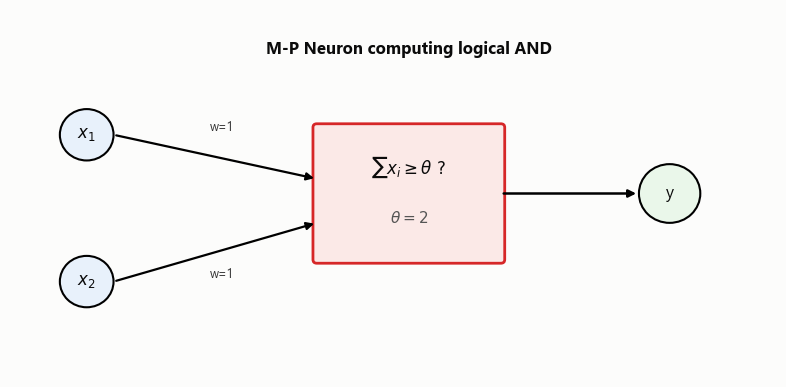

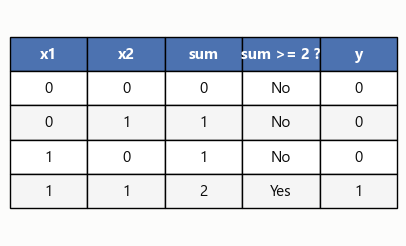

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


# ---------------------------------------------------------------
# M-P Neuron worked example: AND gate
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis('off')

# inputs
ax.add_patch(mpatches.Circle((1, 3.3), 0.35, ec='black', fc='#e8f1fb', lw=1.5, zorder=2))
ax.text(1, 3.3, r"$x_1$", ha='center', va='center', fontsize=12)
ax.add_patch(mpatches.Circle((1, 1.3), 0.35, ec='black', fc='#e8f1fb', lw=1.5, zorder=2))
ax.text(1, 1.3, r"$x_2$", ha='center', va='center', fontsize=12)

# neuron body (summation + threshold)
ax.add_patch(mpatches.FancyBboxPatch((4.0, 1.6), 2.4, 1.8, boxstyle="round,pad=0.05",
                                       linewidth=2, edgecolor='#d62728', facecolor='#fbe9e7', zorder=2))
ax.text(5.2, 2.85, r"$\sum x_i \geq \theta\ ?$", ha='center', va='center', fontsize=12, weight='bold')
ax.text(5.2, 2.15, r"$\theta = 2$", ha='center', va='center', fontsize=11, color='#555')

# output
ax.add_patch(mpatches.Circle((8.6, 2.5), 0.4, ec='black', fc='#eaf7ea', lw=1.5, zorder=2))
ax.text(8.6, 2.5, "y", ha='center', va='center', fontsize=12)

# edges with weight labels (weight = 1 fixed, non-learnable)
ax.annotate('', xy=(4.0, 2.7), xytext=(1.35, 3.3),
            arrowprops=dict(arrowstyle='-|>', lw=1.6, color='black'))
ax.text(2.6, 3.35, "w=1", fontsize=9, color='#333')
ax.annotate('', xy=(4.0, 2.1), xytext=(1.35, 1.3),
            arrowprops=dict(arrowstyle='-|>', lw=1.6, color='black'))
ax.text(2.6, 1.35, "w=1", fontsize=9, color='#333')
ax.annotate('', xy=(8.2, 2.5), xytext=(6.4, 2.5),
            arrowprops=dict(arrowstyle='-|>', lw=1.8, color='black'))

ax.text(5.2, 4.4, "M-P Neuron computing logical AND", ha='center', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()
plt.close()

# ---------------------------------------------------------------
# Truth table rendered as a small table image
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(4.2, 2.6))
ax.axis('off')
data = [
    ["x1", "x2", "sum", "sum >= 2 ?", "y"],
    ["0", "0", "0", "No", "0"],
    ["0", "1", "1", "No", "0"],
    ["1", "0", "1", "No", "0"],
    ["1", "1", "2", "Yes", "1"],
]
table = ax.table(cellText=data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#4c72b0')
        cell.set_text_props(color='white', weight='bold')
    else:
        cell.set_facecolor('#f5f5f5' if row % 2 == 0 else 'white')

plt.tight_layout()
plt.show()
plt.close()



---
### Limitations of the M-P Neuron

- **The threshold $\theta$ and weights are fixed by hand.** There is no mechanism for the neuron to *learn* $\theta$ or the weights from data — a human has to choose them in advance for every new problem.
- **Inputs must be binary** (`0` or `1`). Real-world data (pixel intensities, sensor readings, prices) doesn't naturally fit this.
- **All excitatory inputs are weighted equally** — the model can't express "input A matters twice as much as input B."

> The M-P neuron proved a network of simple units *could* compute logic. What it couldn't do is **learn** — and that gap is exactly what the Perceptron was built to close.

<img src="image/np-neuron-limitation.png" alt="np-neuron-limitation.png" width="580"   >



---
## > From M-P Neuron to Perceptron

The M-P neuron answered "can a simple unit compute something meaningful?" — yes. It did not answer "can that unit improve itself from data?" — no.

The **Perceptron** (Rosenblatt, 1958) closes that gap by making two changes to the M-P neuron:

| | M-P Neuron | Perceptron |
|---|---|---|
| Weights | Fixed, equal (all = 1) | **Learnable**, can differ per input |
| Threshold/Bias | Fixed by hand | **Learnable** (as a bias term) |
| Inputs | Binary only | Real-valued |
| Learns from data? | No | **Yes** |

That one change — letting weights and threshold adjust themselves based on mistakes — turns a fixed logic gate into the first *trainable* model in this notebook, and is the direct predecessor of every neuron used in modern deep learning.


---
---
---
---
# **`Perceptrons`**
---
---
---
---



**Definition:** A perceptron computes a weighted sum of its inputs, adds a bias, and passes the result through a step function that outputs a binary decision.

A Perceptron is the simplest form of a **neural network** that makes decisions by combining inputs with weights and applying an activation function. It is mainly used for binary classification problems. It forms the basic building block of many deep learning models.

$$z = \sum_{i=1}^{n} w_i x_i + b = w^Tx + b$$

$$y = \begin{cases} 1 & \text{if } z \geq 0 \\ 0 & \text{if } z < 0 \end{cases}$$

Compare this to the M-P neuron: the weights $w_i$ and bias $b$ are no longer fixed — they are learned from data, one mistake at a time.



<img src="image/the-perceptrons-1958.jpg" alt="the-perceptrons-1958.jpg" width="500" >


---

### The Perceptron Learning 






--- 
## `Perceptron Convergence Theorem`

When you "train" a perceptron, it starts with a random boundary. It looks at the data one piece at a time. If it misclassifies a point, it tilts and shifts its line slightly to try and fix the mistake.
The Perceptron Convergence Theorem is a mathematical proof that guarantees the following:

- Linearly Separable Data: If a perfect straight line actually exists that can cleanly separate your two categories without any errors, the perceptron is guaranteed to find it.

- Finite Steps: It will not loop forever. It will successfully find that perfect boundary and stop adjusting its weights in a specific, finite number of steps.


> The Catch: If the data is not linearly separable (meaning you need a curve, a circle, or a zig-zag to separate the categories), the simple perceptron will fail completely. It will keep shifting its straight line back and forth in an infinite loop, never settling, because a perfect straight line doesn't exist.



---

<details>
<summary>

**`❓ Question:`**

Assume that we have a set of **linearly separable** data points
$$   x_i \in \mathbb{R}^d,\quad i = 1,2,\ldots,N    $$
where each data point belongs to one of two classes $ y_i \in \{+1,-1\} $

The perceptron predicts **+1** if **( $ w^T x \ge 0  $ )** and **−1** otherwise.

Suppose we apply the **Perceptron Learning Algorithm**, and it successfully converges to a solution $ w^* \in \mathbb{R}^d $ that correctly classifies **all** training data points. Which of the following conditions is (are) guaranteed to hold for every training point?

> **A.**  $   y_i\left(w^{*T}x_i\right)\ge0       \qquad \forall x_i   $

> **B.**  $   y_i\left(w^{*T}x_i\right)\le0       \qquad \forall x_i   $

> **C.**  $   w^{*T}x_i\ge0                        \qquad \forall x_i  $

> **D.**  $   w^{*T}x_i\le0                        \qquad \forall x_i  $



</summary>

---

**`Solution:`**

here, The perceptron classifies a point based on the sign of the expression $w^Tx$.

- `w*ᵀxᵢ` → The **score (decision value)** assigned by the perceptron to point `xᵢ`.
- `yᵢ` → The **true class label** (`+1` or `−1`).
  
  - If $w^Tx \ge 0$, the predicted class is **+1**.
  - If $w^Tx < 0$, the predicted class is **−1**.

Since the perceptron has **successfully converged**, every training point is classified correctly.

> Option A ✅ : $y_i\left(w^{*T}x_i\right)\ge0 \qquad \forall x_i$      

- **$w^{*T}x_i$**: The **score** (or decision value) computed by the perceptron for the input $x_i$.
- **$y_i$**: The **actual class label** of the input (+1 or −1).

Let's verify both cases.

---
- Case 1: Positive class : If  $ y_i = +1,  $ 

then for correct classification, $ w^{*T}x_i \ge 0 $   

Multiplying it by $+1$, gives $$(+1)(w^{*T}x_i) \ge 0  $$

---
- Case 2: Negative class : If  $ y_i = -1, $

then for correct classification,  $ w^{*T}x_i < 0. $

Multiplying by $-1$, gives  $$ (-1)(w^{*T}x_i) > 0. $$

---

which means

$$
y_i(w^{*T}x_i) \ge 0.
$$

Therefore, irrespective of whether the point belongs to class **+1** or **−1**,

$$
y_i(w^{*T}x_i)\ge0
$$

is always satisfied.


> Option B ❌ : $y_i\left(w^{*T}x_i\right)\le0 \qquad \forall x_i$

This is the opposite of Option A.

> Option C ❌ : $w^{*T}x_i\ge0 \qquad \forall x_i$

This says **every** training point has a non-negative score.

However, points belonging to class **−1** must satisfy

$$
w^{*T}x_i < 0.
$$

Therefore, this condition cannot hold for all training points.


> Option D ❌ : $w^{*T}x_i\le0 \qquad \forall x_i$

This says every training point has a non-positive score.

However, points belonging to class **+1** must satisfy

$$
w^{*T}x_i \ge 0.
$$

So this condition also cannot be true for all training points.

</details>

---

---

<details>
<summary>

**`❓ Question:`**

Let a perceptron learn a decision function based on a homogeneous linear separator in the space $R^7$, i.e., the perceptron outputs $+1$ if

$$
w^Tx \ge 0
$$

and $-1$ otherwise, where $w \in R^7$ and $x \in R^7$.

Assuming the training data is perfectly linearly separable, and the perceptron has converged to a valid solution, what is the number of connected regions into which the learned decision boundary divides the space $R^7$?

> **A.** Infinitely many

> **B.** 2

> **C.** 7

> **D.** Cannot be determined without knowing the data distribution

</summary>

---

**`Solution:`**

A **Perceptron** learns a **linear decision boundary**.

The perceptron makes its prediction using

$$
w^Tx \ge 0.
$$

where

- $x$ → Input vector (data point).
- $w$ → Weight vector learned by the perceptron.
- $w^Tx$ → The **score (or decision value)** of the input.

The **decision boundary** is formed where the score becomes zero:

$$
w^Tx = 0.
$$

This equation represents a **hyperplane**.

A hyperplane is the higher-dimensional equivalent of:

| Space | Decision Boundary |
|-------|-------------------|
| $R^1$ | Point |
| $R^2$ | Line |
| $R^3$ | Plane |
| $R^7$ | Hyperplane |

The important property is:

> **A single hyperplane always divides the space into exactly two connected regions (called half-spaces), irrespective of the number of dimensions.**

For example, in $R^2$:

```text
        Region (+)

---------------------------  ← Decision Boundary (wᵀx = 0)

        Region (-)
```

The same idea extends to $R^7$.

Since a **single perceptron always learns one hyperplane**, it can divide the space into **only two connected regions**.

---

> **Option A ❌ :** Infinitely many

A single hyperplane creates only **two** regions, not infinitely many.

---

> **Option B ✅ :** 2

A perceptron learns exactly **one hyperplane**, and one hyperplane always divides the space into **two connected regions (half-spaces)**.

✅ **Option B is Correct.**

---

> **Option C ❌ :** 7

The number of regions is **not related to the number of dimensions**.

Even in $R^7$, one hyperplane still creates only **two** regions.

---

> **Option D ❌ :** Cannot be determined without knowing the data distribution

The number of connected regions depends only on the **decision boundary**, not on the distribution of the data.

Since the perceptron always learns **one linear decision boundary**, the answer is always **2**.

</details>

---

---
## `Strength and limitations of the Perceptron`


### The XOR Problem: Where the Perceptron Breaks

The convergence theorem's catch — "if the data is not linearly separable, the perceptron fails" — has one famous, concrete example: the **XOR (exclusive OR)** logic gate.

| $x_1$ | $x_2$ | AND | XOR |
|---|---|---|---|
| 0 | 0 | 0 | 0 |
| 0 | 1 | 0 | 1 |
| 1 | 0 | 0 | 1 |
| 1 | 1 | 1 | 0 |

AND is linearly separable — one straight line cleanly splits the `0`s from the `1`s. XOR is **not** — the `1`s sit on opposite corners from each other, and so do the `0`s. No single straight line can separate them.



<img src="image/perceptrons-strength-and-limitation.png" alt="perceptrons-strength-and-limitation.png" width="500" >


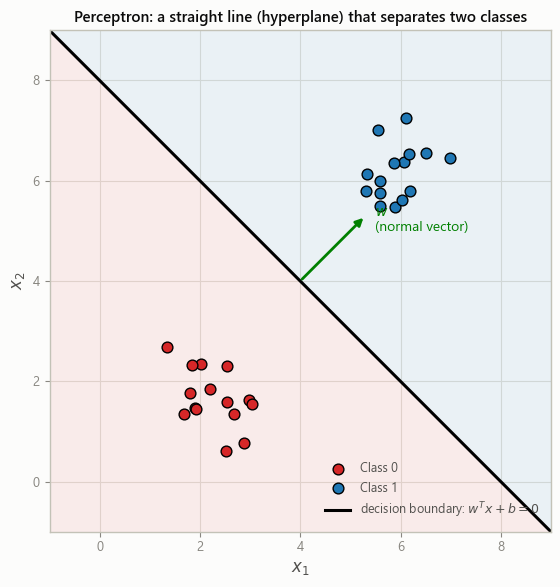

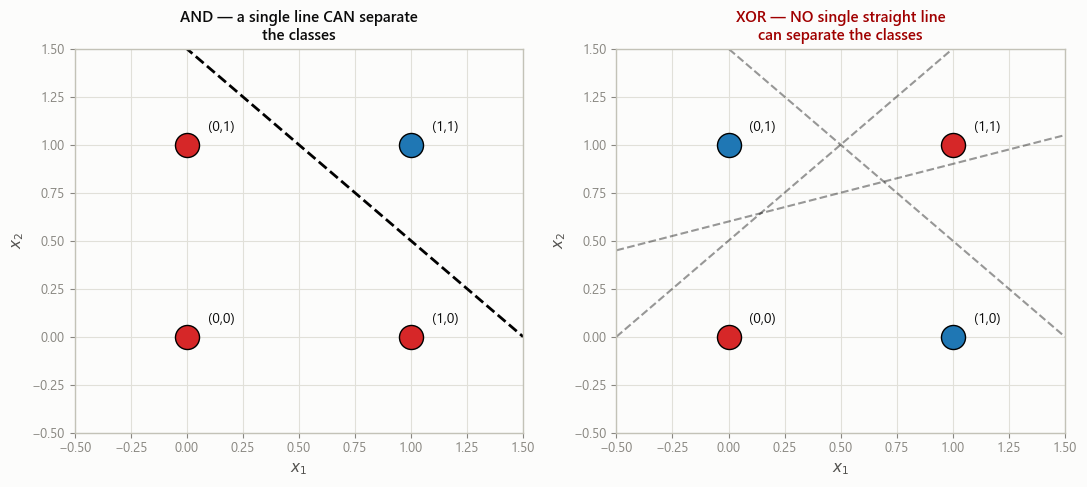

In [24]:
import matplotlib.pyplot as plt
import numpy as np


# ---------------------------------------------------------------
# Geometric view: perceptron as a line separating two classes
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 6))
np.random.seed(1)
class0 = np.random.randn(15, 2) * 0.6 + np.array([2, 2])
class1 = np.random.randn(15, 2) * 0.6 + np.array([6, 6])

ax.scatter(class0[:, 0], class0[:, 1], color='#d62728', label='Class 0', s=60, edgecolor='black', zorder=3)
ax.scatter(class1[:, 0], class1[:, 1], color='#1f77b4', label='Class 1', s=60, edgecolor='black', zorder=3)

x_vals = np.array([-1, 9])
y_vals = -x_vals + 8  # separating line w1*x + w2*y + b = 0 -> x + y - 8 = 0
ax.plot(x_vals, y_vals, 'k-', lw=2.2, label=r'decision boundary: $w^Tx + b = 0$')
ax.fill_between(x_vals, y_vals, 10, color='#1f77b4', alpha=0.08)
ax.fill_between(x_vals, y_vals, -2, color='#d62728', alpha=0.08)

ax.annotate('', xy=(5.3, 5.3), xytext=(4, 4),
            arrowprops=dict(arrowstyle='-|>', lw=2, color='green'))
ax.text(5.5, 5.0, r'$w$' + '\n(normal vector)', fontsize=10, color='green')

ax.set_xlim(-1, 9)
ax.set_ylim(-1, 9)
ax.set_xlabel(r'$x_1$', fontsize=12)
ax.set_ylabel(r'$x_2$', fontsize=12)
ax.set_title('Perceptron: a straight line (hyperplane) that separates two classes', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()
plt.close()

# ---------------------------------------------------------------
# XOR problem: not linearly separable
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# AND (linearly separable) - left panel
ax = axes[0]
pts = {(0,0):0, (0,1):0, (1,0):0, (1,1):1}
for (x, y), label in pts.items():
    color = '#1f77b4' if label == 1 else '#d62728'
    ax.scatter(x, y, s=300, color=color, edgecolor='black', zorder=3)
    ax.annotate(f"({x},{y})", (x, y), textcoords="offset points", xytext=(15, 10), fontsize=10)
xs = np.array([-0.5, 1.5])
ax.plot(xs, 1.5 - xs, 'k--', lw=2)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_title("AND — a single line CAN separate\nthe classes", fontsize=11)
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')

# XOR (not linearly separable) - right panel
ax = axes[1]
pts = {(0,0):0, (0,1):1, (1,0):1, (1,1):0}
for (x, y), label in pts.items():
    color = '#1f77b4' if label == 1 else '#d62728'
    ax.scatter(x, y, s=300, color=color, edgecolor='black', zorder=3)
    ax.annotate(f"({x},{y})", (x, y), textcoords="offset points", xytext=(15, 10), fontsize=10)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.5, 1.5)
ax.set_title("XOR — NO single straight line\ncan separate the classes", fontsize=11, color='#a00000')
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
# draw a few failed attempts
for slope, intercept, alpha in [(1, 0.5, 0.4), (-1, 1.5, 0.4), (0.3, 0.6, 0.4)]:
    xs = np.array([-0.5, 1.5])
    ax.plot(xs, slope*xs + intercept, 'k--', lw=1.5, alpha=alpha)

plt.tight_layout()
plt.show()
plt.close()


---
---
## **`Multi-Layer Perceptron (MLP)`**
---
---



**Definition:** A Multi-Layer Perceptron is a network of perceptrons arranged in layers — an input layer, one or more **hidden layers**, and an output layer — where each neuron's output feeds into every neuron of the next layer.

$$
h_1 = \text{step}(w_{11}x_1 + w_{12}x_2 + b_1) \qquad h_2 = \text{step}(w_{21}x_1 + w_{22}x_2 + b_2)
$$
$$y = \text{step}(v_1 h_1 + v_2 h_2 + c)$$

Each hidden neuron is still just a perceptron — a single straight line. But because the **output neuron combines two lines' worth of information**, the network as a whole can carve out a region no single line could:


`Why This Matters`

- **Depth solves what width (a single wide layer of independent perceptrons) cannot** — the hidden layer's outputs feed into another neuron, not directly into a final vote. That composition is what creates curved/piecewise decision boundaries.
- This is the resolution to the AI Winter triggered by the XOR limitation: the *building block* (the perceptron) was never the problem — the *architecture* (a single layer) was.



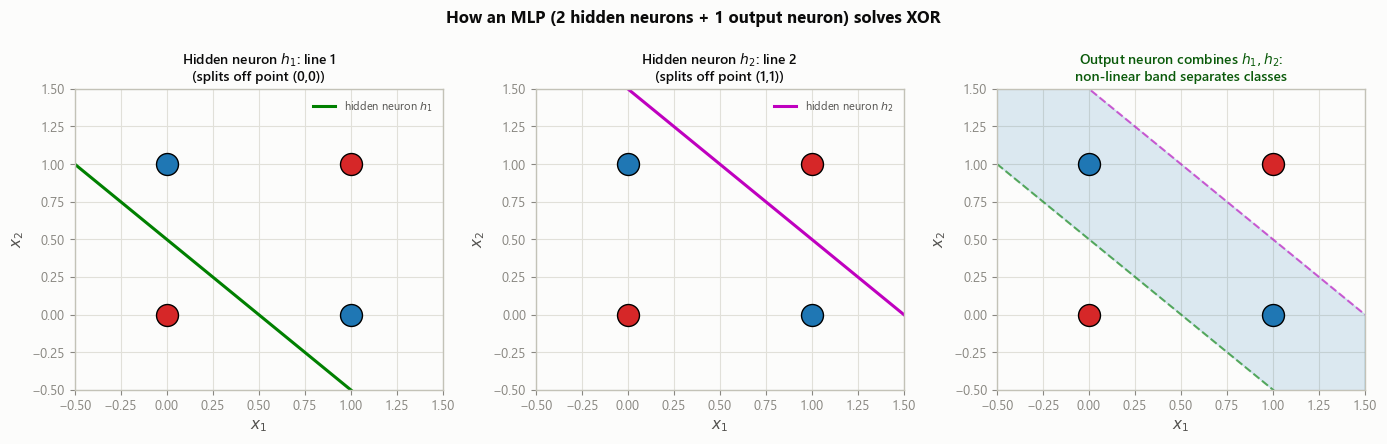

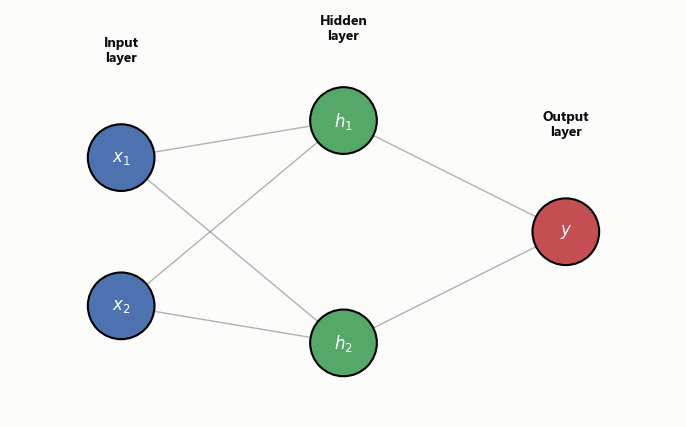

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


# ---------------------------------------------------------------
# MLP solving XOR: two hidden lines combine into a non-linear boundary
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

pts = {(0,0):0, (0,1):1, (1,0):1, (1,1):0}

# Panel 1: hidden neuron 1 (line 1)
ax = axes[0]
for (x, y), label in pts.items():
    color = '#1f77b4' if label == 1 else '#d62728'
    ax.scatter(x, y, s=250, color=color, edgecolor='black', zorder=3)
xs = np.array([-0.5, 1.5])
ax.plot(xs, -xs + 0.5, 'g-', lw=2.2, label=r'hidden neuron $h_1$')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_title(r"Hidden neuron $h_1$: line 1" + "\n(splits off point (0,0))", fontsize=10)
ax.legend(fontsize=8, loc='upper right')

# Panel 2: hidden neuron 2 (line 2)
ax = axes[1]
for (x, y), label in pts.items():
    color = '#1f77b4' if label == 1 else '#d62728'
    ax.scatter(x, y, s=250, color=color, edgecolor='black', zorder=3)
ax.plot(xs, -xs + 1.5, 'm-', lw=2.2, label=r'hidden neuron $h_2$')
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_title(r"Hidden neuron $h_2$: line 2" + "\n(splits off point (1,1))", fontsize=10)
ax.legend(fontsize=8, loc='upper right')

# Panel 3: combined -> non-linear boundary (shaded band)
ax = axes[2]
for (x, y), label in pts.items():
    color = '#1f77b4' if label == 1 else '#d62728'
    ax.scatter(x, y, s=250, color=color, edgecolor='black', zorder=3)
ax.plot(xs, -xs + 0.5, 'g--', lw=1.5, alpha=0.6)
ax.plot(xs, -xs + 1.5, 'm--', lw=1.5, alpha=0.6)
ax.fill_between(xs, -xs + 0.5, -xs + 1.5, color='#1f77b4', alpha=0.15)
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.set_title("Output neuron combines $h_1, h_2$:\nnon-linear band separates classes", fontsize=10, color='#0a5a0a')

for ax in axes:
    ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')

plt.suptitle("How an MLP (2 hidden neurons + 1 output neuron) solves XOR", fontsize=12, weight='bold')
plt.tight_layout()
plt.show()
plt.close()

# ---------------------------------------------------------------
# MLP network structure for this exact example
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
ax.axis('off')

layer_x = [0, 3, 6]
positions = [
    [(0, 1), (0, -1)],           # input layer: x1, x2
    [(3, 1.5), (3, -1.5)],       # hidden layer: h1, h2
    [(6, 0)],                    # output layer: y
]
labels = [[r'$x_1$', r'$x_2$'], [r'$h_1$', r'$h_2$'], [r'$y$']]
colors = ['#4c72b0', '#55a868', '#c44e52']

for l in range(len(positions) - 1):
    for (x0, y0) in positions[l]:
        for (x1, y1) in positions[l + 1]:
            ax.plot([x0, x1], [y0, y1], color='gray', lw=1, alpha=0.6, zorder=1)

for l, layer in enumerate(positions):
    for (x, y), lab in zip(layer, labels[l]):
        circ = plt.Circle((x, y), 0.45, color=colors[l], ec='black', lw=1.5, zorder=2)
        ax.add_patch(circ)
        ax.text(x, y, lab, ha='center', va='center', fontsize=12, color='white', weight='bold', zorder=3)

ax.text(0, 2.3, "Input\nlayer", ha='center', fontsize=10, weight='bold')
ax.text(3, 2.6, "Hidden\nlayer", ha='center', fontsize=10, weight='bold')
ax.text(6, 1.3, "Output\nlayer", ha='center', fontsize=10, weight='bold')

ax.set_xlim(-1.5, 7.5)
ax.set_ylim(-2.5, 3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()
plt.close()


---
---
---
---
# **The modern `artificial` neuron**
---
---
---


**Definition:** A modern (artificial) neuron computes a weighted sum of its inputs plus a bias, then passes that sum through a **differentiable, non-linear activation function** — replacing the M-P/Perceptron's hard step function.

$$z = w^Tx + b \qquad\qquad a = f(z)$$

- $z$ (sometimes called the **pre-activation**) is exactly the same linear combination as the perceptron.
- $f$ is the **activation function** — smooth curves like Sigmoid, Tanh, ReLU (covered in detail shortly), instead of a hard `0`/`1` cutoff.
- $a$ (the **activation**) is what actually gets passed to the next layer.

The word "differentiable" is the whole point: a step function has a derivative of `0` everywhere (except one undefined point), so it gives no usable signal for gradient-based learning. Swapping it for a smooth $f$ is what allows **backpropagation** to work at all — a preview of where this notebook is heading.

<img src="image/modern-neuron-with-differentiable-activation-function.png" alt="modern-neuron-with-differentiable-activation-function.png" width="560" >

<img src="image/notes/1784277805528.png" alt="1784277805528.png" width="480"    >




--- 

### Importance of Non-Linear Activations 

Think of a neural network as a series of transformations. A "fully connected layer" mathematically performs a linear operation: it multiplies the input data by a matrix of weights and adds a bias vector ($y = Wx + b$). Activation functions (like ReLU, Sigmoid) are non-linear. They are the "magic" that allows neural networks to bend and twist decision boundaries to solve complex, real-world problems.

> What happens if we remove the non-linear activations and just stack fully connected layers? Let's look at the math for two layers:

**Layer 1 output:** $y_1 = W_1 x + b_1$

**Layer 2 output:** $y_2 = W_2 y_1 + b_2$

`If we plug Layer 1 into Layer 2, we get:`
$$y_2 = W_2(W_1 x + b_1) + b_2$$

$$y_2 = (W_2 W_1)x + (W_2 b_1 + b_2)$$

> Notice what happened? Because matrix multiplication is associative, $(W_2 W_1)$ just becomes a brand new, single weight matrix ($W_{new}$), and $(W_2 b_1 + b_2)$ becomes a brand new single bias ($b_{new}$). No matter if you stack 2 layers or 2,000 layers, without non-linearities, the entire network collapses mathematically into one single linear equation ($y = W_{new} x + b_{new}$). `It reduces to a single linear transformation, losing expressive power.`








From Sensation to Numbers 


<img src="image/numerization-trick-from-sensation-to-number.png" alt="numerization-trick-from-sensation-to-number.png" width="580" >

  

<img src="image/the-numerization-self-driving-car.png" alt="the-numerization-self-driving-car.png" width="400" >





<img src="image/numerization-encoding-categories.png" alt="numerization-encoding-categories.png" width="400" >



<img src="image/the-function-trick.png" alt="the-function-trick.png" width="400" >



<img src="image/parametrization-trick.png" alt="parametrization-trick.png" width="400" >



<img src="image/learning-problem-to-optimization-probelm.png" alt="learning-problem-to-optimization-probelm.png" width="400" >


---
---
---
---
# Network Architecture
---
---
---
---



**Definition:** A network's *architecture* is how its neurons are organized into layers and connected to each other. Three terms describe any architecture:

- **Layer** — a group of neurons that all receive the same input and compute in parallel.
- **Width** — the number of neurons in a given layer.
- **Depth** — the number of layers stacked one after another (more layers = "deeper" network — this is literally where "deep" in Deep Learning comes from).



---
---
## Feedforward Network Architecture
---
---



A **feedforward network** (the simplest architecture) connects every neuron in one layer to every neuron in the next, with information flowing strictly forward — `input → hidden layer(s) → output` — never backward or sideways. This is sometimes called a **fully connected** or **dense** network.



<img src="image/feedforward-network-topology.png" alt="feedforward-network-topology.png" width="400" >



<img src="image/standard-feedforward-model.png" alt="standard-feedforward-model.png" width="400" >

<img src="image/forward-pass-vectorization-layer.png" alt="forward-pass-vectorization-layer.png" width="400" >

<img src="image/forward-pass-vectorization-layer-2.png" alt="forward-pass-vectorization-layer-2.png" width="400" >


### Hands-on Example : Feedforward Network Architecture

<img src="image/feed-forward-architecture-example.png" alt="feed-forward-architecture-example.png" width="680" >



### Universal Approximation Theorem (UAT) 



**Statement (informal):** a feedforward neural network with just **one hidden layer**, given **enough neurons** in that layer and a suitable non-linear activation function, can approximate *any* continuous function to arbitrary precision.

The Catch: "Enough Neurons" Can Mean an Enormous Number

UAT guarantees a wide-enough single layer *exists* — it says nothing about how wide, and it says nothing about whether that width is learnable or practical. In practice, a single hidden layer often needs an impractically large number of units to approximate anything non-trivial:


<img src="image/linear-regression-vs-artificial-nn.png" alt="Linear Regression vs Artificial NN" width="400">

<br>

<img src="image/uat-statement.png" alt="uat-statement.png" width="550">


<img src="image/key-takeaway-uat.png" alt="key-takeaway-uat.png" width="500" >




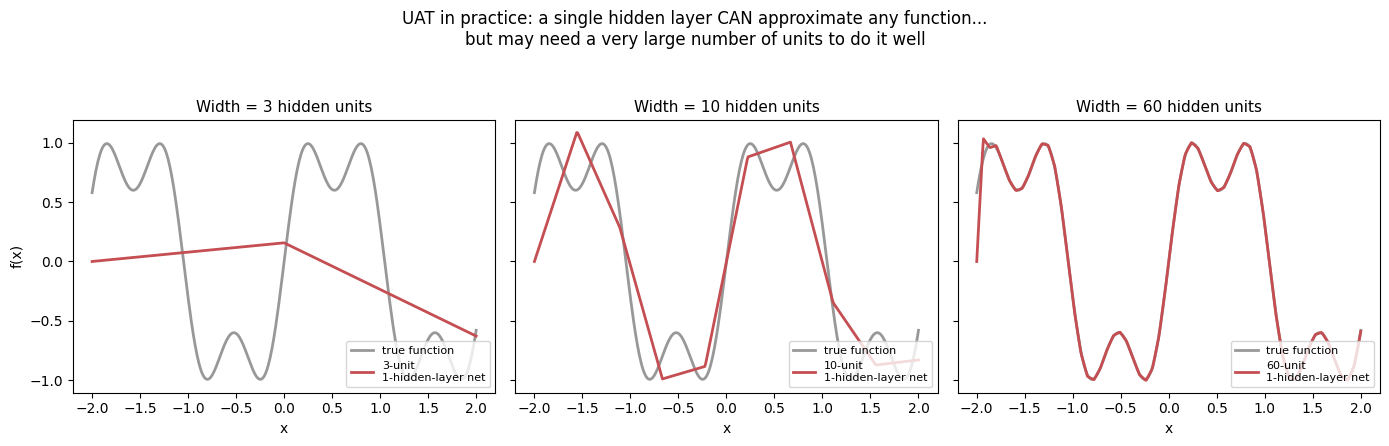

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------
# UAT catch: approximating a wiggly function with increasing
# hidden-layer width (a single hidden layer, ReLU units), vs.
# the same job done by a small DEEP network. Shows "wide but
# shallow can technically do it, but needs a lot more units."
# ---------------------------------------------------------------

def target_fn(x):
    return np.sin(3 * x) + 0.4 * np.sin(9 * x)

x = np.linspace(-2, 2, 400)
y_true = target_fn(x)

rng = np.random.default_rng(3)

def relu(z):
    return np.maximum(0, z)

def shallow_approx(x, n_units):
    # random "trained-looking" hidden units approximating the curve
    # (illustrative fit via random features + least squares, not real training)
    centers = np.linspace(-2, 2, n_units)
    H = relu(np.subtract.outer(x, centers) * rng.uniform(2, 5, n_units))
    w, *_ = np.linalg.lstsq(H, y_true, rcond=None)
    return H @ w

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
widths = [3, 10, 60]
for ax, n in zip(axes, widths):
    y_approx = shallow_approx(x, n)
    ax.plot(x, y_true, color='#333', lw=2, label='true function', alpha=0.5)
    ax.plot(x, y_approx, color='#c44e52', lw=2, label=f'{n}-unit\n1-hidden-layer net')
    ax.set_title(f"Width = {n} hidden units", fontsize=11)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlabel('x')

axes[0].set_ylabel('f(x)')
plt.suptitle("UAT in practice: a single hidden layer CAN approximate any function...\nbut may need a very large number of units to do it well",
             fontsize=12, y=1.05)
plt.tight_layout()
plt.show()
plt.close()


## Forward Pass 




**Recap definition:** the forward pass is the process of pushing an input $x$ through every layer of the network — each layer computing $z=Wx+b$ then $a=f(z)$ — until the final layer produces a prediction $\hat{y}$. 

This was already built and traced by hand in the Network Architecture section above; nothing new happens here mechanically, this is just naming the full pass as a single term used throughout the rest of the notebook.


<img src="image/the-forwardpass-representation.png" alt="the-forwardpass-representation.png" width="400" >



## Activation Functions 
// Non-linear Activation Functions 


<img src="image/why-need-activation-function.png" alt="why-need-activation-function.png" width="500" >

**Importance of Non-Linearity**

-   Real-world data is rarely linearly separable.
-   Non-linear functions allow neural networks to form curved decision boundaries, making them capable of handling complex patterns (e.g., classifying apples vs. bananas under varying colors and shapes).
-   They ensure networks can model advanced problems like image recognition, NLP and speech processing.





---
**`❓ Question:`** If you remove all nonlinear activations (ReLU, sigmoid, etc.) from a deep neural network but keep multiple fully connected layers, what happens?

**👉 Answer:** The network will become a linear model, and it will not be able to learn complex patterns in the data. Losing expressive power.

*Expressive Power:* The ability of a model to represent complex patterns in the data. A model with expressive power can learn complex patterns, while a model with limited expressive power may not be able to learn complex patterns.

---


---
---
### Sigmoid Activation Function
---
---


The sigmoid function $\sigma(z) = \frac{1}{1+e^{-z}}$ is a classic activation function that squishes any input number into a small, predictable range. Let's evaluate the options based on its graph:

- **`It outputs between 0 and 1`** : If you plug in a massive positive number, $e^{-z}$ becomes almost 0, so the formula becomes $$\frac{1} { (1+0)} = 1$$ 
If you plug in a massive negative number, $e^{-z}$ becomes huge, so the formula becomes $$ \frac{1}{1 + \text{huge number}} = \frac{1} {1 + (\text{huge number})} = 0 $$

<img src="image/traditional-activation-sigmoid.png" alt="traditional-activation-sigmoid.png" width="550" >

- **`Vanishing gradient`** : The gradient (slope) of the sigmoid curve is very steep in the middle (near $z=0$), but at the extreme left and right, the curve becomes perfectly flat. A flat curve has a slope of $0$. During backpropagation, multiplying by these $0$ (or near-zero) gradients causes the network to stop learning. This is the infamous "vanishing gradient" problem.

- **`Not Zero-centered`** : A zero-centered function outputs values around zero (e.g., from -1 to 1). Because Sigmoid outputs strictly between 0 and 1, it is centered at 0.5. (The Tanh activation function is the zero-centered alternative to Sigmoid).

- **`Differentiable everywhere`** : It is a smooth, continuous "S" curve with no sharp corners (unlike ReLU, which has a non-differentiable corner at 0).

Range of derivative of sigmoid function is between 0 and 0.25
  


<img src="image/traditional-activation-sigmoid-limitation.png" alt="traditional-activation-sigmoid-limitation.png" width="450" >


<img src="image/derivative-of-sigmoid.png" alt="derivative-of-sigmoid.png" width="450" >


<img src="image/sigmoid-function-and-its-derivative.png" alt="sigmoid-function-and-its-derivative.png" width="450" >



---
--- 
### Tanh Activation Function
---
---




[Tanh function](https://www.geeksforgeeks.org/deep-learning/tanh-activation-in-neural-network/) (hyperbolic tangent function) is a shifted version of the sigmoid, allowing it to stretch across the y-axis.

-   Outputs values from -1 to +1.
-   Enables modeling of complex data patterns.
-   Commonly used in hidden layers due to its zero-centered output, facilitating easier learning for subsequent layers.

<img src="image/traditional-activation-tanh.png" alt="traditional-activation-tanh.png" width="400" >



<img src="image/traditional-activation-tanh-limitation.png" alt="traditional-activation-tanh-limitation.png" width="400" >



---
<details>
<summary>

**`❓ Question:`**

Consider a simple 2-layer neural network with the following specifications:
- Input: a single real number x
- Hidden Layer: 1 neuron with sigmoid activation
- Output Layer: 1 neuron with unknown activation function
- All weights = 1, all biases = 0

The network behaves as follows:

- When x = 0, the final output is 0.5
- When x = 1, the final output is 0.731

Which of the following is the most likely activation function of the output neuron?
</summary>


</details>

---


---
---
### ReLU Activation Function 
---
---


ReLU (Rectified Linear Unit) is defined mathematically as $f(z) = \max(0, z)$. It acts as a gate: it 
lets positive numbers pass through unchanged, and ruthlessly crushes negative numbers to zero.

| Property ||
| --- |-|
| `Outputs` | between 0 and infinity: <br> For any input $z$, if $z > 0$, the output is $z$ itself. If $z < 0$, the output is $0$. |
| `Derivative`| If $z > 0$, the function is just $y = z$, which is a straight line with a slope (derivative) of exactly $1$. If $z < 0$, the function is a flat horizontal line at $y = 0$, which has a slope of $0$. (True) | 
|`Avoids Vanishing Gradients` | ReLU does not suffer from the vanishing gradient problem in the positive region. Because the derivative in the positive domain is forever exactly $1$, gradients flowing backward through positive neurons do not shrink. |
| `Differentiable everywhere except at 0`| ReLU has a sharp corner at $z=0$, where it transitions from flat to linear. This means the derivative is not defined at exactly $z=0$. <br> However, in practice, this is not a major issue for training neural networks. |

---
**Sparse Activation**: ReLU outputs zero for all negative inputs, which means it can create sparse representations. This sparsity can lead to more efficient computations and can help mitigate the vanishing gradient problem in deep networks. 


<img src="image/traditional-activation-relu.png" alt="traditional-activation-relu.png" width="400" >


<img src="image/traditional-activation-relu-limitation.png" alt="traditional-activation-relu-limitation.png" width="400" >



---
#### Fixing the Dying ReLU Problem

**The problem, stated precisely:** if a ReLU neuron's pre-activation $z$ ever lands consistently negative for every input in the training data, its output is always `0`, and — since ReLU's derivative for $z<0$ is also `0` — no gradient ever flows back through it. That neuron stops learning permanently. This is the "dying ReLU" problem.

Three widely-used fixes, all keeping ReLU's simplicity but removing the flat-zero region:

| Variant | Formula | Idea |
|---|---|---|
| **Leaky ReLU** | $f(z) = \max(\alpha z,\, z)$, typically $\alpha=0.01$–$0.1$ | Let negative inputs through at a small slope instead of exactly `0` — gradient never fully dies. |
| **GELU** (Gaussian Error Linear Unit) | smooth curve, no closed hard corner | Used as the default activation in Transformers (BERT, GPT). Smoothly blends in a small negative dip instead of a hard cutoff. |
| **Swish** | $f(z) = z \cdot \sigma(z)$ | Self-gated: the neuron's own sigmoid decides how much of itself to let through. Similar shape to GELU. |


<img src="image/fixing-dying-problem-in-relu.png" alt="fixing-dying-problem-in-relu.png" width="400" >


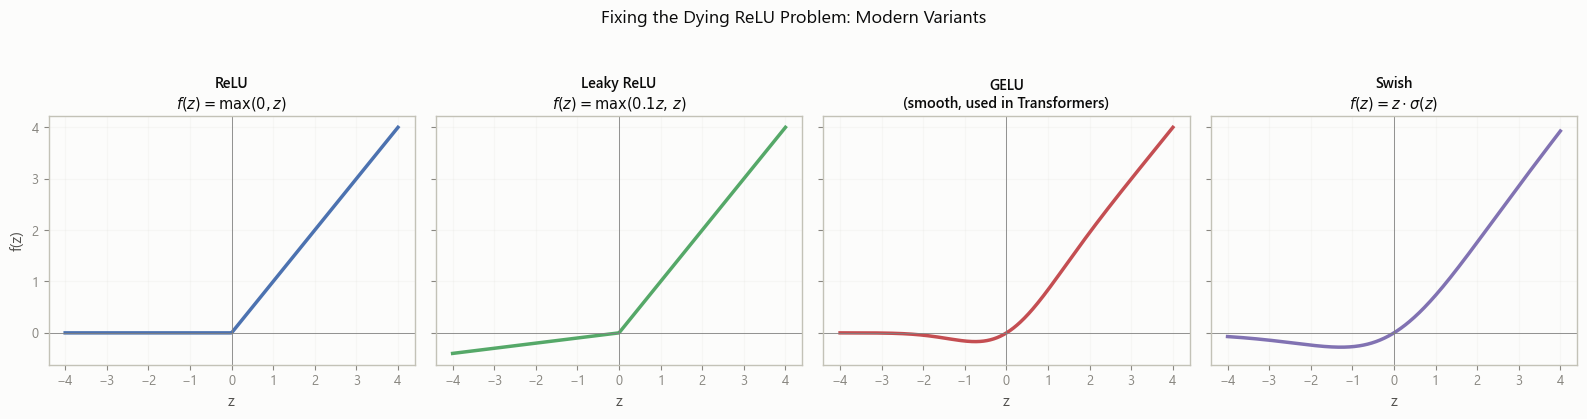

In [27]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------
# ReLU family: ReLU vs Leaky ReLU vs GELU vs Swish, all on one plot
# ---------------------------------------------------------------
z = np.linspace(-4, 4, 400)

relu = np.maximum(0, z)
leaky_relu = np.where(z > 0, z, 0.1 * z)

def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x**3)))

def swish(x, beta=1.0):
    return x / (1 + np.exp(-beta * x))

gelu_vals = gelu(z)
swish_vals = swish(z)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

funcs = [
    (relu, "ReLU\n$f(z)=\\max(0,z)$", '#4c72b0'),
    (leaky_relu, "Leaky ReLU\n$f(z)=\\max(0.1z,\\,z)$", '#55a868'),
    (gelu_vals, "GELU\n(smooth, used in Transformers)", '#c44e52'),
    (swish_vals, "Swish\n$f(z)=z\\cdot\\sigma(z)$", '#8172b2'),
]

for ax, (vals, title, color) in zip(axes, funcs):
    ax.plot(z, vals, color=color, lw=2.5)
    ax.axhline(0, color='gray', lw=0.6)
    ax.axvline(0, color='gray', lw=0.6)
    ax.set_title(title, fontsize=10.5)
    ax.set_xlabel('z')
    ax.grid(alpha=0.2)

axes[0].set_ylabel('f(z)')
plt.suptitle("Fixing the Dying ReLU Problem: Modern Variants", fontsize=13, y=1.04)
plt.tight_layout()
plt.show()
plt.close()


---

<details>
<summary>

**`❓ Question:`**

Given ReLU activation function

$$
f(z)=\max(0,z)
$$

Which of the following are true?

> **A.** Its derivative is 1 when $(z>0)$ and 0 when $(z<0)$

> **B.** It avoids vanishing gradients in positive domain

> **C.** It is differentiable everywhere including at $(z=0)$

> **D.** It induces sparsity in activations

</summary>

---

**`Solution:`**

The **ReLU (Rectified Linear Unit)** activation function is defined as

$$
f(z)=\max(0,z)
$$

where:

- $z$ → Input to the activation function.
- If $z>0$, ReLU returns $z$.
- If $z\le0$, ReLU returns $0$.

---

> **Option A ✅ :** Its derivative is 1 when $(z>0)$ and 0 when $(z<0)$


The derivative of ReLU is

$$
f'(z)=
\begin{cases}
1, & z>0\\
0, & z<0
\end{cases}
$$

- For **positive inputs**, the graph is a straight line with slope **1**.
- For **negative inputs**, the output is a constant ($0$), so the slope is **0**.

(At $z=0$, the derivative is **not defined**, which is discussed in Option C.)


---

> **Option B ✅ :** It avoids vanishing gradients in positive domain


The **gradient** is simply the derivative used during backpropagation.

For positive inputs,

$$
f'(z)=1.
$$

Since the gradient is **1**, it does **not become very small** as in Sigmoid or Tanh.

This helps gradients flow through deep networks and reduces the **Vanishing Gradient Problem** for positive activations.


---

> **Option C ❌ :** It is differentiable everywhere including at $(z=0)$


At

$$
z=0,
$$

ReLU changes direction abruptly.

- The slope from the **left** is

$$
0
$$

- The slope from the **right** is

$$
1.
$$

Since the left-hand and right-hand derivatives are different, the derivative at $z=0$ **does not exist**.

Therefore, ReLU is **not differentiable at $z=0$**.


---

> **Option D ✅ :** It induces sparsity in activations


For every negative input,

$$
f(z)=0.
$$

This means many neurons produce an output of **zero**.

Having many zero activations is called **sparsity**.

Sparse activations make the network more efficient and often improve learning.


</details>

---

### Popular Activation Functions

<img src="image/popular-activation-functions.png" alt="popular-activation-functions.png" width="900" >
<br>



---

<details>
<summary>

**`❓ Question:`** Consider a network of 100 layers where each layer performs the following operation:  

$$ 
x_{(t+1)} = ReLU⁡(−1.0⋅xt) , (no bias)
$$
If a scalar input $x_o =0.7$ is fed to the network, what will be the output after 100 layers?
</summary>

**`Solution`**

To solve this, let's trace the input through the first few layers:

**Layer 0 (Input):** 

$x_{0} = 0.7$

**Layer 1:**

$ Operation  :   x_1​ = ReLU(−1.0⋅x_0​) $

$ Calculation  :   x_1​ = ReLU(−1.0⋅0.7) = ReLU(−0.7) $

$ Definition of ReLU  :   ReLU(z) = max(0,z) $

$ Result  :     x_1​ = max(0,−0.7) = 0.0 $

**Layer 2:**
    
$ Operation: x_2​ = ReLU(−1.0⋅x_1​) $
        
$ Calculation: x_2​ = ReLU(−1.0 ⋅ 0.0) = ReLU(0.0) = 0.0 $

Once the input hits 0.0 at the first layer, every subsequent layer will also result in 0.0 because the ReLU activation function clamps any negative input to 0, and −1.0⋅0\=0.

Therefore, the output after 100 layers is **0.0**.

</details>

---

---

<details>
<summary>

**`❓ Question:`**

You design a neural network without any activation functions (only linear transformations). Which statements are true?

> **A.** The network reduces to a single linear transformation regardless of depth.

> **B.** Such a model cannot represent XOR function.

> **C.** Gradient descent will diverge in training.

> **D.** Adding more layers improves representation power.

</summary>

---

**`Solution:`**

A neural network **without activation functions** performs only **linear transformations**.

A linear transformation is an operation like

$$
y = Wx + b
$$

where:

- **$x$** → Input vector.
- **$W$** → Weight matrix.
- **$b$** → Bias vector.
- **$y$** → Output after the transformation.

If multiple linear layers are stacked, (increase depth of the network)

$$
y = W_3(W_2(W_1x+b_1)+b_2)+b_3
$$

they can always be combined into a **single linear transformation**.

$$
y = W_2W_1x + W_2b_1 + b_2
$$

Notice that

- $W_2W_1$ is simply another weight matrix.
- $W_2b_1+b_2$ is simply another bias vector.

Let's rename them as

$$
W = W_2W_1
$$

and

$$
b = W_2b_1+b_2
$$

The equation now becomes

$$
y = Wx+b
$$


Therefore, adding more linear layers **does not increase the expressive power** of the network.

---

> **Option A ✅ :** The network reduces to a single linear transformation regardless of depth.

Since the composition of multiple linear transformations is still a **linear transformation**, the entire network behaves exactly like one linear layer.

Hence, regardless of how many layers are added, the network can always be represented as

$$
y = Wx + b.
$$

---

> **Option B ✅ :** Such a model cannot represent XOR function.

The **XOR (Exclusive OR)** problem is **not linearly separable**.

A network consisting only of linear transformations can only learn **linear decision boundaries**.

Since XOR requires a **non-linear decision boundary**, such a network cannot represent it.

---

> **Option C ❌ :** Gradient descent will diverge in training.

**Gradient Descent** is an optimization algorithm used to **update the model's weights** so that the loss decreases.

A typical weight update is

$$
\text{New Weight} = \text{Old Weight} - \text{Learning Rate} \times \text{Gradient}
$$

The statement claims that **gradient descent will always diverge** if the network has no activation functions.

This is **not true**.

A network without activation functions is simply a **linear model**, and linear models (such as **Linear Regression**) are commonly trained using Gradient Descent without any issues.

Whether Gradient Descent converges or diverges depends on factors such as:

- Learning rate
- Data
- Weight initialization
- Loss function

It **does not depend** on the presence or absence of activation functions.

Therefore, removing activation functions **does not automatically** cause Gradient Descent to diverge.

---

> **Option D ❌ :** Adding more layers improves representation power.

Since multiple linear layers collapse into a single linear transformation,

$$
W_3W_2W_1x = Wx,
$$

adding more linear layers does **not** make the model more expressive.

To increase representation power, **non-linear activation functions** like ReLU, Sigmoid, or Tanh are required.

</details>

---

---

<details>
<summary>

**`❓ Question:`**

Consider the dataset:

$$
D_1=\{(1,1,+1),(-1,1,-1),(1,-1,-1),(-1,-1,+1)\}
$$

in $\mathbb{R}^2$, where the third coordinate denotes the class label. Which of the following statements is/are true?

> **A.** $D_1$ is linearly separable.

> **B.** The perceptron learning algorithm will converge on $D_1$.

> **C.** The perceptron learning algorithm will not converge on $D_1$.

</summary>

---

**`Solution:`**

Each data point is represented as

$$
(x_1,x_2,\text{class label})
$$

where:

- $x_1,x_2$ → Coordinates of the data point.
- Third value → The actual class label (`+1` or `-1`).

The dataset is

| Point | Label |
|-------|-------|
| $(1,1)$ | +1 |
| $(-1,1)$ | -1 |
| $(1,-1)$ | -1 |
| $(-1,-1)$ | +1 |

If we plot these points, we get

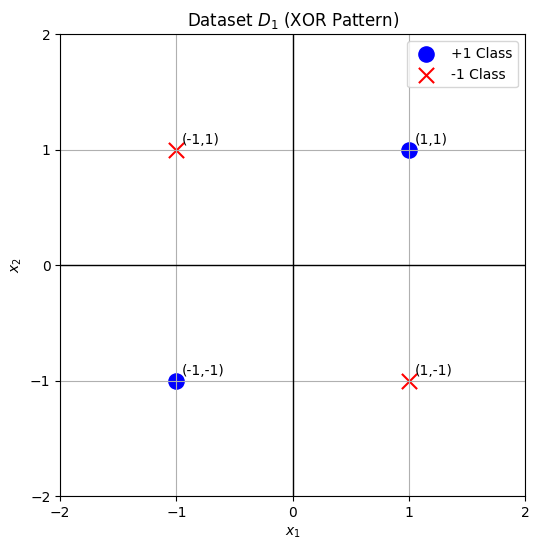

Notice the pattern:

- The **diagonal corners** belong to class **+1**.
- The other two corners belong to class **−1**.

This is the famous **XOR pattern**.

A single straight line **cannot separate** these two classes.

Therefore, the dataset is **not linearly separable**.

---

> **Option A ❌ :** $D_1$ is linearly separable.

A dataset is **linearly separable** if a **single straight line** can separate all positive and negative points.

Since this dataset forms an XOR pattern, no single line can separate the two classes.

---

> **Option B ❌ :** The perceptron learning algorithm will converge on $D_1$.

The **Perceptron Convergence Theorem** states:

> A perceptron converges **only if** the dataset is linearly separable.

Since $D_1$ is **not linearly separable**, the perceptron can never find a line that correctly classifies every point.

Hence, it will **not converge**.

---

> **Option C ✅ :** The perceptron learning algorithm will not converge on $D_1$.

Since the dataset is **not linearly separable**, the perceptron will keep updating its weights forever and never reach a solution that correctly classifies every point.

Therefore,

</details>

---

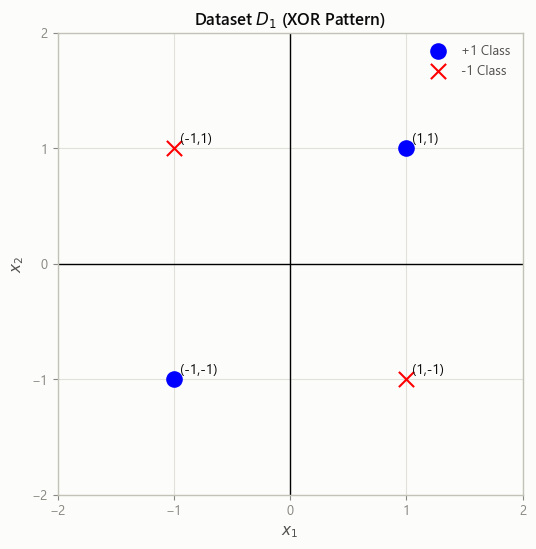

In [28]:
# part of the above question
import matplotlib.pyplot as plt

# Dataset
positive = [(1, 1), (-1, -1)]
negative = [(-1, 1), (1, -1)]

# Separate x and y coordinates
px, py = zip(*positive)
nx, ny = zip(*negative)

# Create figure
plt.figure(figsize=(6, 6))

# Plot points
plt.scatter(px, py, color='blue', s=120, marker='o', label='+1 Class')
plt.scatter(nx, ny, color='red', s=120, marker='x', label='-1 Class')

# Annotate points
for x, y in positive:
    plt.text(x + 0.05, y + 0.05, f'({x},{y})', fontsize=10)

for x, y in negative:
    plt.text(x + 0.05, y + 0.05, f'({x},{y})', fontsize=10)

# Draw x and y axes
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Formatting
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xticks([-2, -1, 0, 1, 2])
plt.yticks([-2, -1, 0, 1, 2])

plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('Dataset $D_1$ (XOR Pattern)')
plt.grid(True)
plt.legend()

plt.show()

---

<details>
<summary>

**`❓ Question:`**

Consider a simple 2-layer neural network with the following specifications:

- Input: a single real number $x$
- Hidden Layer: 1 neuron with **ReLU** activation
- Output Layer: 1 neuron with **unknown activation function**
- All weights = 1, all biases = 0

The network behaves as follows:

- When $x=0$, the final output is $0$
- When $x=2$, the final output is $2$

Which of the following is /are the most likely activation function of the output neuron?

> **A.** Sigmoid

> **B.** Tanh

> **C.** ReLU

> **D.** Linear / Identity

</summary>

---

**`Solution:`**

The network consists of **two layers**.

`Hidden Layer`

The hidden neuron uses the **ReLU activation function**:

$$
\text{ReLU}(z)=\max(0,z)
$$

Since

- Weight = $w$ = 1
- Bias = $b$ = 0

the hidden neuron computes

$$
z = wx + b = x
$$

and its output becomes

$$
h=\max(0,x).
$$

---

For the given inputs:

When

$$
x=0,
$$

$$
h=\max(0,0)=0.
$$

When

$$
x=2,
$$

$$
h=\max(0,2)=2.
$$

So the **input reaching the output neuron** is

| Input $x$ | Hidden Output $h$ |
|-----------|-------------------|
| 0 | 0 |
| 2 | 2 |

---

The output neuron also has

- Weight = 1
- Bias = $b$ = 0

Therefore, its input is simply

$$
z= wh + b = h
$$

The only unknown is the **activation function**.

---

> **Option A ❌ :** Sigmoid

The sigmoid function is

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

For

$$
z=0,
$$

it produces

$$
\sigma(0)=0.5,
$$

not **0**.

Also,

$$
\sigma(2)\approx0.88,
$$

not **2**.

Therefore, Sigmoid cannot produce the given outputs.

---

> **Option B ❌ :** Tanh

The tanh function is

$$
\tanh(z).
$$

It produces

$$
\tanh(0)=0
$$

which matches the first condition.

However,

$$
\tanh(2)\approx0.964,
$$

not **2**.

Therefore, Tanh cannot produce the required outputs.

---

> **Option C ✅ :** ReLU

The ReLU function is

$$
\max(0,z).
$$

For

$$
z=0,
$$

Output = 0 ✅

For

$$
z=2,
$$

Output = 2 ✅

It matches both observations.

---

> **Option D ✅ :** Linear / Identity

The Identity (Linear) activation is

$$
f(z)=z.
$$

For

$$
z=0,
$$

Output = 0 ✅

For

$$
z=2,
$$

Output = 2 ✅

It also matches both observations.

---

Therefore, both **ReLU** and **Linear (Identity)** are consistent with the observed outputs.

</details>

---

---

<details>
<summary>

**`❓ Question:`**

Consider the following architecture for a fully connected artificial neural network:

- Input Layer: $x \in \mathbb{R}^5$
- Hidden Layer: 80 hidden layers with 10 neurons in each
- Output Layer: 1 neuron

Suppose the hidden layers use the **ReLU** activation function while the output layer uses the **Sigmoid** activation function.

Let

$$
x=
\begin{bmatrix}
-6\\
2\\
1\\
-3\\
2
\end{bmatrix}
$$

All the weights are initialized to **1**. Ignore the biases.

What will be the output of this neural network in the first forward pass?

</summary>

---

**`Solution:`**

The network has

- **5 input features**
- **80 hidden layers**
- **10 neurons in each hidden layer**
- **All weights = 1**
- **All biases = 0**

Since every weight is **1**, each neuron simply computes the **sum of all its inputs**.

---

**`Input Layer → Hidden Layer 1`**

The input is

$$
x=
\begin{bmatrix}
-6\\
2\\
1\\
-3\\
2
\end{bmatrix}
$$

Each neuron computes

$$
(-6)+2+1+(-3)+2=-4.
$$

The hidden layer uses **ReLU**,

$$
\text{ReLU}(z)=\max(0,z).
$$

Therefore,

$$
\text{ReLU}(-4)=0.
$$

Every neuron in the first hidden layer outputs

$$
0.
$$

So Hidden Layer 1 becomes

$$
[0,0,0,\ldots,0].
$$

---

**`Hidden Layer 2`**

Each neuron now receives ten zeros.

The weighted sum is

$$
0+0+\cdots+0=0.
$$

Applying ReLU,

$$
\text{ReLU}(0)=0.
$$

So every neuron again outputs

$$
0.
$$

---

**`Remaining Hidden Layers`**

Exactly the same thing happens in every remaining hidden layer.

Once all activations become zero, they remain zero throughout the network.

Therefore,

every hidden layer outputs

$$
[0,0,\ldots,0].
$$

---

**`Output Layer`**

The output neuron receives ten zeros.

Its weighted sum is

$$
0.
$$

The output layer uses the **Sigmoid** activation function,

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

Substituting

$$
z=0,
$$

we get

$$
\sigma(0)=\frac{1}{2}=0.5.
$$

---

**Final Answer**

$$
\boxed{0.5}
$$

</details>

---


## Guid for Choosing Activation Functions
<img src="image/guid-for-chosing-activation-function.png" alt="guid-for-chosing-activation-function.png" width="640" >

---

<details>
<summary>

**`❓ Question:`**

Consider the following fully connected network with one input layer containing two neurons, one hidden layer containing two neurons and one output layer with three neurons.

<img src="image/question-neurons-diagram.png" alt="question-neurons-diagram.png" width="320" >

The weight matrices are initialized as follows

$$
W_1 =
\begin{bmatrix}
0 & 1\\
1 & 0
\end{bmatrix},
\qquad
W_2 =
\begin{bmatrix}
1 & 0\\
0 & 0\\
0 & 1
\end{bmatrix}
$$

What is the shape of

$$ \frac{\partial L}{\partial W_2} \; ? $$

> **A.** $2 \times 2$

> **B.** $1 \times 3$

> **C.** $2 \times 3$

> **D.** $3 \times 2$

</summary>

---

**`Solution:`**

Before solving the question, let's understand the notation used.

- **$L$** → The **Loss Function**. It measures **how wrong the neural network's prediction is**.

  - Smaller loss → Better predictions.
  - Larger loss → Worse predictions.

- **$W_2$** → The **weight matrix** connecting the **Hidden Layer** to the **Output Layer**.

- **$ \dfrac{\partial L}{\partial W_2}$** → The **gradient of the loss with respect to the weight matrix $W_2$**.

  It tells us:

  > **"If we slightly change the weights in $W_2$, how much will the loss change?"**

  During training, the optimizer (such as Gradient Descent) uses this gradient to update the weights and reduce the loss.

---

The question is asking only for the **shape** of $$ \frac{\partial L}{\partial W_2}. $$

Notice that the given weight matrix

$$
W_2 =
\begin{bmatrix}
1 & 0\\
0 & 0\\
0 & 1
\end{bmatrix}
$$

has

- **3 rows**
- **2 columns**

Therefore,

$$ W_2 \text{ has shape } 3 \times 2. $$

Now think about what the gradient stores.

Every number inside $W_2$ is a **weight**.

For example,

$$
W_2=
\begin{bmatrix}
w_1 & w_2\\
w_3 & w_4\\
w_5 & w_6
\end{bmatrix}
$$

Each weight has its **own gradient**.

That means the gradient matrix looks like

$$ \frac{\partial L}{\partial W_2} =
\begin{bmatrix}
\dfrac{\partial L}{\partial w_1} & \dfrac{\partial L}{\partial w_2}\\
\dfrac{\partial L}{\partial w_3} & \dfrac{\partial L}{\partial w_4}\\
\dfrac{\partial L}{\partial w_5} & \dfrac{\partial L}{\partial w_6}
\end{bmatrix}
$$

Notice that there is **one gradient value for every weight**.

Since $W_2$ contains **3 rows and 2 columns**, its gradient must also contain **3 rows and 2 columns**.

Therefore,

$$ \frac{\partial L}{\partial W_2} \text{ has shape } 3 \times 2. $$

---

> **Option A ❌ :** $2 \times 2$

Incorrect. The gradient must have the same shape as $W_2$, which is not $2 \times 2$.

---

> **Option B ❌ :** $1 \times 3$

Incorrect. This shape does not match the weight matrix.

---

> **Option C ❌ :** $2 \times 3$

Incorrect. This is the transpose of the required shape.

---

> **Option D ✅ :** $3 \times 2$

The gradient has the **same shape** as the weight matrix because every weight has exactly one corresponding gradient.

Therefore,

$$ \frac{\partial L}{\partial W_2} = 3 \times 2. $$

✅ **Option D is Correct.**

---

💡 **Remember**

For **any neural network**,

$$ \boxed{\text{Shape}\left(\frac{\partial L}{\partial W}\right)=\text{Shape}(W)} $$

because every weight has **exactly one corresponding gradient**.

</details>

---

---

<details>
<summary>

**`❓ Question:`**

Consider a neural network for a **regression** problem with input

$$ x \in \mathbb{R}^{10}. $$

The network has

- **2 hidden layers**
- Each hidden layer has **5 sigmoid neurons**
- The output layer has **1 neuron** and uses the **sigmoid activation function**

Enter the **number of parameters** in the network.

</summary>

---

**`Solution:`**

Before solving the question, let's understand a few important terms.

- **Neuron** → A processing unit in a neural network.

- **Input Layer** → The first layer that receives the input data.

  Since

  $$ x \in \mathbb{R}^{10}, $$

  the input vector has **10 values (features)**.

  Therefore, the input layer has **10 input neurons** (also called **input units**).

  These input neurons **do not perform any computation**. They simply pass the input values to the next layer.

- **Parameters** → The values that the neural network learns during training.

  These are:

  - **Weights** → Connections between neurons.
  - **Biases** → One extra value associated with every neuron except the input neurons.

Therefore,

$$ \boxed{\text{Total Parameters}=\text{Total Weights}+\text{Total Biases}} $$

---

The network architecture is

```text
Input Layer (10 neurons)
        │
        ▼
Hidden Layer 1 (5 neurons)
        │
        ▼
Hidden Layer 2 (5 neurons)
        │
        ▼
Output Layer (1 neuron)
```

Now calculate the parameters layer by layer.

---

### Input Layer → Hidden Layer 1

The input layer has **10 neurons**.

The first hidden layer has **5 neurons**.

Each hidden neuron is connected to **all 10 input neurons**.

Therefore,

$$ \text{Weights}=10\times5=50. $$

Each hidden neuron has one bias.

Since there are **5 hidden neurons**,

$$ \text{Biases}=5. $$

So,

$$ \text{Parameters}=50+5=55. $$

---

### Hidden Layer 1 → Hidden Layer 2

Both hidden layers contain **5 neurons**.

Every neuron in Hidden Layer 2 receives input from all 5 neurons of Hidden Layer 1.

Therefore,

$$ \text{Weights}=5\times5=25. $$

Again, each neuron has one bias.

$$ \text{Biases}=5. $$

So,

$$ \text{Parameters}=25+5=30. $$

---

### Hidden Layer 2 → Output Layer

The second hidden layer has **5 neurons**.

The output layer has **1 neuron**.

Therefore,

$$ \text{Weights}=5\times1=5. $$

The output neuron has one bias.

$$ \text{Biases}=1. $$

So,

$$ \text{Parameters}=5+1=6. $$

---

### Total Parameters

Now add the parameters from all layers.

$$ \text{Total Parameters}=55+30+6=91. $$

Therefore,

$$ \boxed{91} $$

is the total number of trainable parameters.

---

💡 **Easy Formula**

For any layer,

$$ \boxed{\text{Parameters}=(\text{Input Neurons}\times\text{Output Neurons})+\text{Output Neurons}} $$

where

- **Input Neurons × Output Neurons** → Number of weights.
- **Output Neurons** → Number of biases.

This formula can be applied **layer by layer** for any fully connected neural network.

</details>

---



# Loss Function 




Now that a forward pass can turn any input $x$ into a prediction $\hat{y}$, we need a way to measure how *wrong* that prediction is. That's the job of a **loss function**.

**Definition:** a loss function $L(\hat{y}, y)$ measures how wrong a single prediction is — a single number, small when $\hat{y}$ is close to $y$, large when it's far off. This is the $L(\theta)$ from the "Learning as Optimization" equation earlier; different tasks need different loss functions.



---
#### Mean Squared Error (MSE) — for Regression
---


Used when $\hat{y}$ is a continuous number (predicting a price, a temperature, a coordinate):

$$\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Squaring does two things: it makes errors always positive (so overestimates and underestimates don't cancel out), and it punishes large errors disproportionately more than small ones.


<img src="image/loss-function(regression-task).png" alt="loss-function(regression-task).png" width="600" >



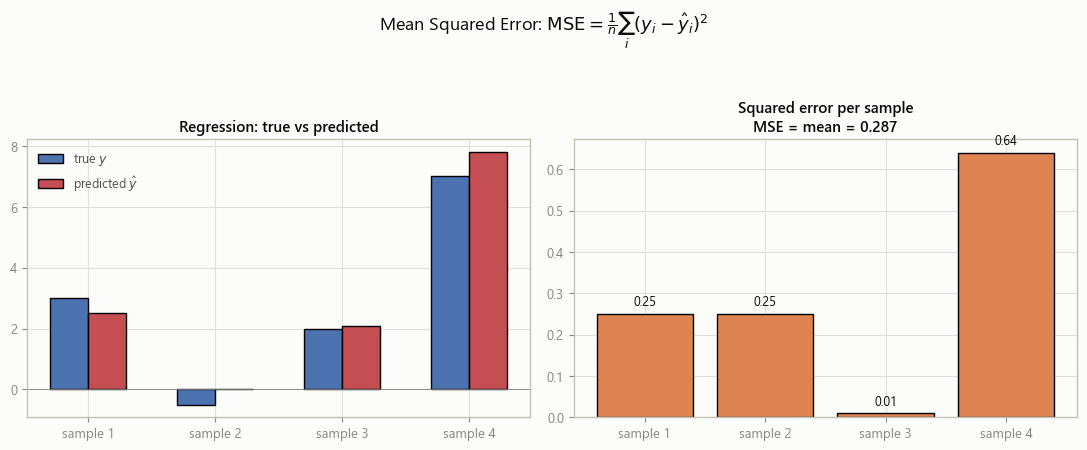

In [29]:
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------
# MSE worked example (regression)
# ---------------------------------------------------------------
y_true = np.array([3.0, -0.5, 2.0, 7.0])
y_pred = np.array([2.5, 0.0, 2.1, 7.8])
sq_err = (y_true - y_pred) ** 2
mse = sq_err.mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

ax = axes[0]
idx = np.arange(len(y_true))
ax.bar(idx - 0.15, y_true, width=0.3, label='true $y$', color='#4c72b0', edgecolor='black')
ax.bar(idx + 0.15, y_pred, width=0.3, label='predicted $\\hat{y}$', color='#c44e52', edgecolor='black')
ax.set_xticks(idx)
ax.set_xticklabels([f"sample {i+1}" for i in idx])
ax.legend(fontsize=9)
ax.set_title("Regression: true vs predicted", fontsize=11)
ax.axhline(0, color='gray', lw=0.6)

ax = axes[1]
bars = ax.bar(idx, sq_err, color='#dd8452', edgecolor='black')
for bar, v in zip(bars, sq_err):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}", ha='center', fontsize=9)
ax.set_xticks(idx)
ax.set_xticklabels([f"sample {i+1}" for i in idx])
ax.set_title(f"Squared error per sample\nMSE = mean = {mse:.3f}", fontsize=11)

plt.suptitle(r"Mean Squared Error: $\mathrm{MSE}=\frac{1}{n}\sum_i(y_i-\hat{y}_i)^2$", fontsize=13, y=1.04)
plt.tight_layout()
plt.show()
plt.close()


---
#### Cross-Entropy Loss — for Classification
---


Used when $\hat{y}$ is a probability distribution over classes (the output of Softmax, from the Activation Functions section). For a single example where the true class is $c$:

$$L = -\log(\hat{p}_c)$$

where $\hat{p}_c$ is the probability the model assigned to the *correct* class. Only the true class's predicted probability matters — the loss doesn't care how the remaining probability was split among the wrong classes.

<img src="image/loss-function-classification-task.png" alt="loss-function-classification-task.png" width="500" >



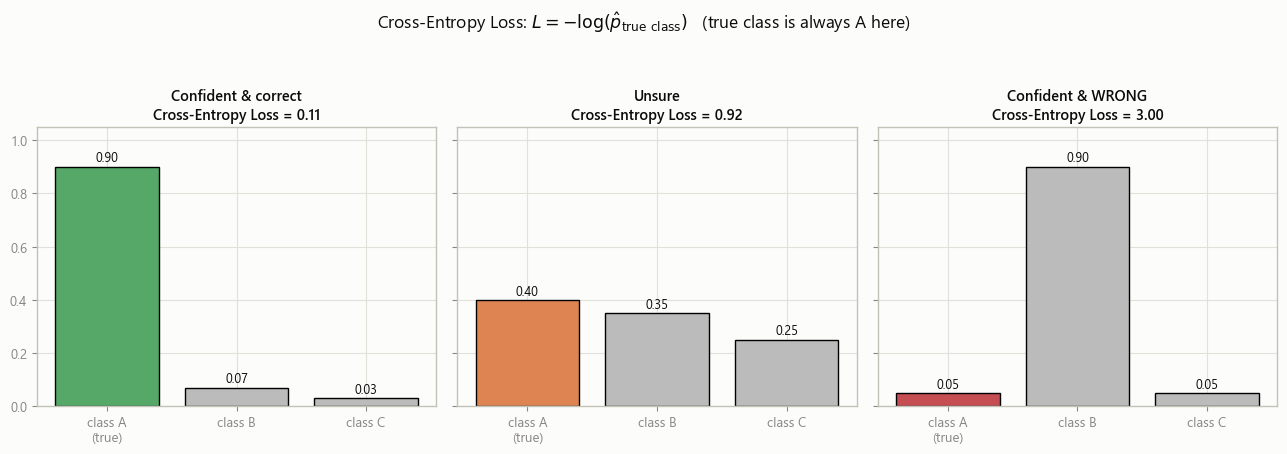

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Cross-Entropy worked example (classification) -- confidence matters
# ---------------------------------------------------------------
# true class is "class A" (one-hot [1,0,0]); two different model predictions
pred_confident_correct = np.array([0.90, 0.07, 0.03])
pred_unsure = np.array([0.40, 0.35, 0.25])
pred_confident_wrong = np.array([0.05, 0.90, 0.05])

def cross_entropy(p_true_idx, probs):
    return -np.log(probs[p_true_idx])

ce_good = cross_entropy(0, pred_confident_correct)
ce_unsure = cross_entropy(0, pred_unsure)
ce_bad = cross_entropy(0, pred_confident_wrong)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.3), sharey=True)
scenarios = [
    (pred_confident_correct, ce_good, "Confident & correct", '#55a868'),
    (pred_unsure, ce_unsure, "Unsure", '#dd8452'),
    (pred_confident_wrong, ce_bad, "Confident & WRONG", '#c44e52'),
]
labels = ['class A\n(true)', 'class B', 'class C']
for ax, (probs, ce, title, color) in zip(axes, scenarios):
    bars = ax.bar(labels, probs, color=[color if i == 0 else '#bbb' for i in range(3)], edgecolor='black')
    for bar, v in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}", ha='center', fontsize=9)
    ax.set_title(f"{title}\nCross-Entropy Loss = {ce:.2f}", fontsize=10.5)
    ax.set_ylim(0, 1.05)

plt.suptitle(r"Cross-Entropy Loss: $L=-\log(\hat{p}_{\text{true class}})$   (true class is always A here)",
             fontsize=12.5, y=1.05)
plt.tight_layout()
plt.show()
plt.close()


---

<details>
<summary>

**`❓ Question:`**

You are training an artificial neural network (ANN) for a **regression task** to predict house prices. After inspecting the target variable (price) in your dataset, you observe that while few prices are within a predictable range, there are a handful of extremely expensive mansions and a few properties sold under unusual circumstances that are severe outliers.

Your primary goal is to build a model that performs well on typical houses, without letting its predictions be overly skewed by these rare, extreme values. Along with that you also desire for smoother convergence.

Which loss function should you primarily consider for this task?

> **A.** Mean Squared Error (MSE)

> **B.** Sum Squared Error (SSE)

> **C.** Huber Loss

> **D.** Binary Cross Entropy Loss

</summary>

---

**`Solution:`**

Before solving the question, let's understand the terms used.

- **Regression Task** → Predicts a **continuous numerical value**, such as house price, salary, or temperature.
- **Loss Function** → Measures how far the model's prediction is from the actual value. During training, the model tries to **minimize this loss**.
- **Outliers** → Data points that are **very different** from the rest of the data. Here, extremely expensive mansions are outliers because their prices are much larger than typical houses.

The question tells us that:

- We want the model to perform well on **typical houses**.
- We **do not** want rare, extremely expensive houses to dominate the learning process.
- We also want **smooth convergence** during training.

---

> **Option A ❌ : Mean Squared Error (MSE)**

The Mean Squared Error is

$$
\text{MSE}=\frac{1}{n}\sum(\text{Prediction}-\text{Actual})^2
$$

It **squares the error**.

This means large errors become **much larger**.

Example:

| Error | Squared Error |
|-------|---------------|
| 2 | 4 |
| 10 | 100 |

An outlier with a large error contributes a huge loss, causing the model to focus too much on those rare examples.

Since the question specifically says we **don't want outliers to dominate**, MSE is not the best choice.

---

> **Option B ❌ : Sum Squared Error (SSE)**

SSE is

$$
\text{SSE}=\sum(\text{Prediction}-\text{Actual})^2
$$

It also squares the error, making it even more sensitive to outliers.

The only difference from MSE is that it **doesn't divide by the number of samples**.

Therefore, it has the same drawback regarding outliers.

---

> **Option C ✅ : Huber Loss**

Huber Loss combines the advantages of **MSE** and **MAE (Mean Absolute Error)**.

- For **small errors**, it behaves like **MSE**, giving smooth optimization.
- For **large errors (outliers)**, it behaves like **MAE**, reducing the influence of extreme values.

Therefore,

- Typical house prices are learned well.
- Outliers do not dominate the training.
- Training remains smooth.

This is exactly what the question asks for.

✅ **Option C is Correct.**

---

> **Option D ❌ : Binary Cross Entropy Loss**

Binary Cross Entropy is used for **binary classification**, where the output is one of two classes (such as Yes/No or 0/1).

House price prediction is a **regression** problem, not a classification problem.

Therefore, Binary Cross Entropy is not suitable.

---


| Loss Function | Best Used For | Handles Outliers Well? |
|--------------|---------------|------------------------|
| **MSE** | Regression | ❌ No |
| **SSE** | Regression | ❌ No |
| **Huber Loss** | Regression with Outliers | ✅ Yes |
| **Binary Cross Entropy** | Binary Classification | ❌ Not for Regression |

Therefore,

✅ **Final Answer: Option C (Huber Loss)**

</details>

---

---
---
---
---
# Gradient Descent 
---
---
---
---


<img src="image/gradient-desent-the-intution.png" alt="gradient-desent-the-intution.png" width="620"    >


## Prerequisite: Derivative

**Definition:** the derivative of a function $f$ at a point $x$, written $f'(x)$, is the **slope of the tangent line** to the curve at that point — how steeply, and in which direction, the function is changing right there.



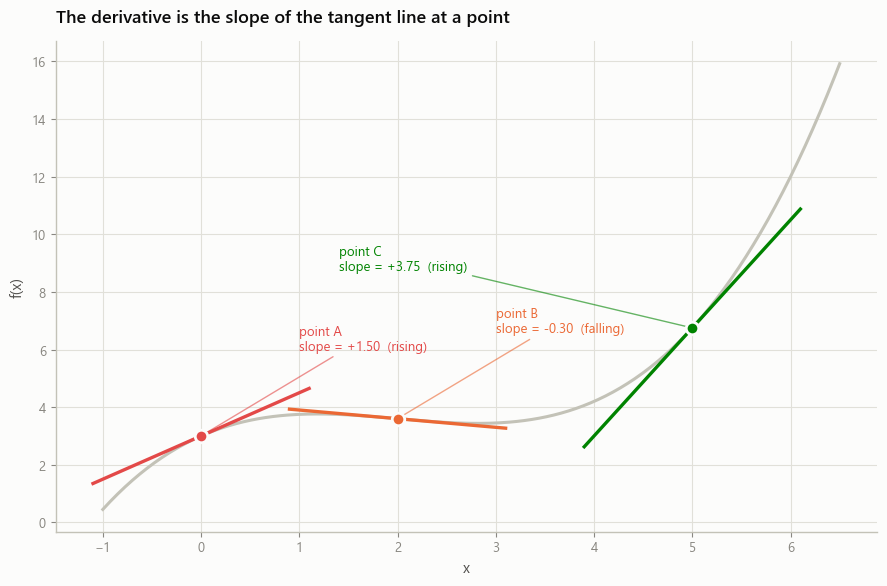

In [31]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style (self-contained, no external file) ---
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, GREEN, ORANGE, RED = "#2a78d6", "#008300", "#eb6834", "#e34948"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 11, "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK_PRIMARY,
    "axes.titlesize": 12, "axes.titleweight": "medium", "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_SECONDARY,
})

def clean_spines(ax, keep=("left", "bottom")):
    for side, spine in ax.spines.items():
        if side not in keep:
            spine.set_visible(False)
        else:
            spine.set_color(BASELINE)
            spine.set_linewidth(1.0)

# =================================================================
# Diagram : derivative = slope of tangent line
# =================================================================
def f(x): return 0.15 * x**3 - 0.9 * x**2 + 1.5 * x + 3
def fprime(x): return 0.45 * x**2 - 1.8 * x + 1.5

x = np.linspace(-1, 6.5, 300)
y = f(x)
points = [0.0, 2.0, 5.0]
point_labels = ['A', 'B', 'C']
point_colors = [RED, ORANGE, GREEN]

fig, ax = plt.subplots(figsize=(9, 6))
clean_spines(ax)
ax.plot(x, y, color=BASELINE, lw=2.2, zorder=1)

for px, lab, col in zip(points, point_labels, point_colors):
    py = f(px)
    slope = fprime(px)
    tx = np.linspace(px - 1.1, px + 1.1, 2)
    ty = py + slope * (tx - px)
    ax.plot(tx, ty, color=col, lw=2.4, zorder=3)
    ax.plot(px, py, 'o', color=col, markersize=9, markeredgewidth=2,
            markeredgecolor=SURFACE, zorder=4)
    direction = 'rising' if slope > 0 else 'falling' if slope < 0 else 'flat'
    xytext = (px + 1.0, py + 3.0) if px < 4 else (px - 3.6, py + 2.0)
    ax.annotate(f"point {lab}\nslope = {slope:+.2f}  ({direction})",
                xy=(px, py), xytext=xytext, fontsize=9.5, color=col,
                arrowprops=dict(arrowstyle='-', color=col, lw=1, alpha=0.6))

ax.set_xlabel('x', color=INK_SECONDARY)
ax.set_ylabel('f(x)', color=INK_SECONDARY)
ax.set_title("The derivative is the slope of the tangent line at a point",
             fontsize=13, loc='left', pad=14)
plt.tight_layout()
plt.show()



`From Slope to "Downhill Direction"`

Here's the idea that makes gradient descent work: if you're standing on a curve and want to move toward the **minimum** (the lowest point), the slope tells you exactly which way to step.

- If the slope is **positive** (curve rising to the right), the minimum is to your **left** — step in the negative direction.
- If the slope is **negative** (curve falling to the right), the minimum is to your **right** — step in the positive direction.

In both cases: **step in the direction opposite the slope's sign.** That's the entire idea behind the minus sign in gradient descent.





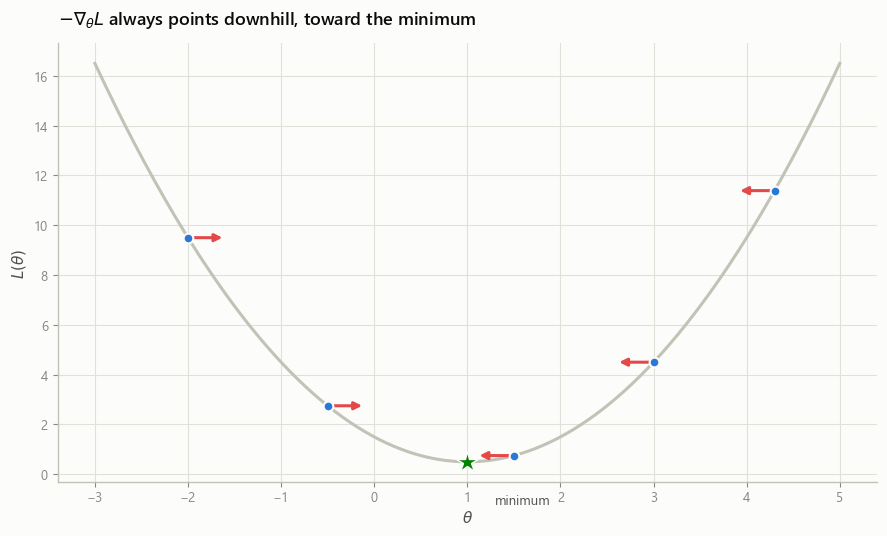

In [32]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style (self-contained, no external file) ---
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, GREEN, ORANGE, RED = "#2a78d6", "#008300", "#eb6834", "#e34948"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 11, "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK_PRIMARY,
    "axes.titlesize": 12, "axes.titleweight": "medium", "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_SECONDARY,
})

def clean_spines(ax, keep=("left", "bottom")):
    for side, spine in ax.spines.items():
        if side not in keep:
            spine.set_visible(False)
        else:
            spine.set_color(BASELINE)
            spine.set_linewidth(1.0)


# =================================================================
# Diagram : negative gradient always points downhill
# =================================================================
def bowl(t): return (t - 1) ** 2 + 0.5
def bowl_grad(t): return 2 * (t - 1)

t = np.linspace(-3, 5, 300)
yb = bowl(t)
sample_pts = [-2, -0.5, 1.5, 3, 4.3]

fig, ax = plt.subplots(figsize=(9, 5.5))
clean_spines(ax)
ax.plot(t, yb, color=BASELINE, lw=2.2, zorder=1)
ax.plot(1, bowl(1), '*', color=GREEN, markersize=16, markeredgewidth=1,
        markeredgecolor=SURFACE, zorder=4)
ax.annotate('minimum', xy=(1, bowl(1)), xytext=(1.3, -1.2), fontsize=9.5, color=INK_SECONDARY)

for sx in sample_pts:
    sy = bowl(sx)
    g = bowl_grad(sx)
    dx = -0.4 * np.sign(g) if g != 0 else 0
    ax.annotate('', xy=(sx + dx, sy), xytext=(sx, sy),
                arrowprops=dict(arrowstyle='-|>', color=RED, lw=2.2))
    ax.plot(sx, sy, 'o', color=BLUE, markersize=7, markeredgewidth=1.5,
            markeredgecolor=SURFACE, zorder=3)

ax.set_xlabel(r'$\theta$', color=INK_SECONDARY)
ax.set_ylabel(r'$L(\theta)$', color=INK_SECONDARY)
ax.set_title(r"$-\nabla_\theta L$ always points downhill, toward the minimum",
             fontsize=13, loc='left', pad=14)
plt.tight_layout()
plt.show()

---
---
## The Single-Variable Update Rule
---
---
Putting together — the derivative tells you slope, and negative slope points downhill — gives the actual **gradient descent update rule**:

$$\theta \leftarrow \theta - \eta f'(\theta)$$

Read this as: "the new $\theta$ equals the old $\theta$, minus a small step in the direction the derivative points." $\eta$ (eta) is the **learning rate** — a small positive number controlling how big that step is.



<img src="image/gradient-desent-loss-landscape.png" alt="gradient-desent-loss-landscape.png" width="620"    >

<img src="image/gradient-desent-in-action.png" alt="gradient-desent-in-action.png" width="400"    >


---

### Worked Example, By Hand

Let $L(\theta) = \theta^2$ (a simple bowl-shaped loss, minimum at $\theta=0$), starting at $\theta_0 = 4$, with $\eta = 0.1$.

The derivative is $L'(\theta) = 2\theta$. Step 1, by hand:

$$\theta_1 = \theta_0 - \eta \cdot L'(\theta_0) = 4 - 0.1 \times (2 \times 4) = 4 - 0.8 = 3.2$$

Step 2, same rule applied again:

$$\theta_2 = 3.2 - 0.1 \times (2 \times 3.2) = 3.2 - 0.64 = 2.56$$

Repeating this same single line of arithmetic, over and over, is the entire gradient descent algorithm:

Notice the steps get *smaller* automatically as $\theta$ approaches the minimum — not because $\eta$ changed, but because the slope itself ($2\theta$) shrinks as $\theta \to 0$. Gradient descent naturally slows down as it nears a minimum, without needing to be told to.

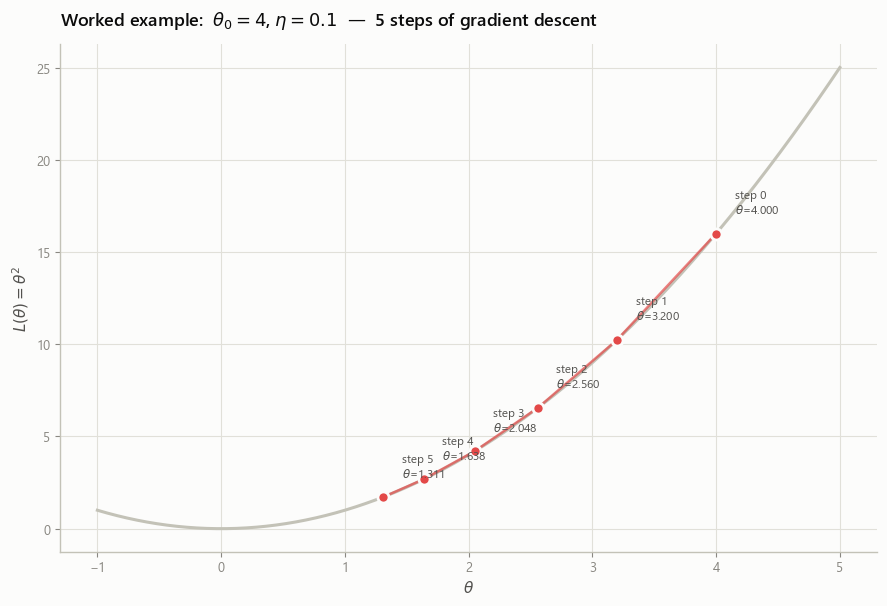

0 4.0 16.0
1 3.2 10.24
2 2.56 6.5536
3 2.048 4.1943
4 1.6384 2.6844
5 1.3107 1.718


In [33]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style (self-contained) ---
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, GREEN, ORANGE, RED = "#2a78d6", "#008300", "#eb6834", "#e34948"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 11, "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK_PRIMARY,
    "axes.titlesize": 12, "axes.titleweight": "medium", "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_SECONDARY,
})

def clean_spines(ax, keep=("left", "bottom")):
    for side, spine in ax.spines.items():
        if side not in keep:
            spine.set_visible(False)
        else:
            spine.set_color(BASELINE)
            spine.set_linewidth(1.0)


# =================================================================
# Worked example: theta0=4, eta=0.1, L(theta)=theta^2, 5 steps
# =================================================================
def L(t): return t ** 2
def dL(t): return 2 * t

lr = 0.1
theta = 4.0
path = [theta]
for _ in range(5):
    theta = theta - lr * dL(theta)
    path.append(theta)
path = np.array(path)

t_range = np.linspace(-1, 5, 300)

fig, ax = plt.subplots(figsize=(9, 6.2))
clean_spines(ax)
ax.plot(t_range, L(t_range), color=BASELINE, lw=2.2, zorder=1)
ax.plot(path, L(path), '-', color=RED, lw=1.8, zorder=2, alpha=0.7)
ax.plot(path, L(path), 'o', color=RED, markersize=8, markeredgewidth=2,
        markeredgecolor=SURFACE, zorder=3)

for i, (tv, lv) in enumerate(zip(path, L(path))):
    ax.annotate(f"step {i}\n" + r"$\theta$" + f"={tv:.3f}",
                xy=(tv, lv), xytext=(tv + 0.15, lv + 1.1),
                fontsize=8.5, color=INK_SECONDARY)

ax.set_xlabel(r'$\theta$', color=INK_SECONDARY)
ax.set_ylabel(r'$L(\theta) = \theta^2$', color=INK_SECONDARY)
ax.set_title(r"Worked example:  $\theta_0=4$, $\eta=0.1$  —  5 steps of gradient descent",
             fontsize=13, loc='left', pad=14)
plt.tight_layout()
plt.show()
plt.close()
for i, (tv, lv) in enumerate(zip(path, L(path))):
    print(i, round(tv, 4), round(lv, 4))


---
## Generalizing to Many Parameters: The Gradient

Real models don't have one parameter — they have thousands, millions, or billions ($w_1, w_2, \ldots, b_1, b_2, \ldots$, all the weights and biases across every layer). The single-variable rule needs to generalize.

**Definition:** for a function $L$ of several parameters $\theta = [\theta_1, \theta_2, \ldots]$, the **gradient** $\nabla_\theta L$ is a *vector* containing the **partial derivative** with respect to each parameter — how much $L$ changes if you nudge *just that one* parameter, holding all others fixed:

$$\nabla_\theta L = \left[\frac{\partial L}{\partial \theta_1},\ \frac{\partial L}{\partial \theta_2},\ \ldots\right]$$


---

### Worked Example — Two Parameters

Let $L(\theta_1, \theta_2) = \theta_1^2 + \theta_2^2$, evaluated at the point $(\theta_1,\theta_2) = (3, 2)$:

$$\frac{\partial L}{\partial \theta_1} = 2\theta_1 = 6 \qquad\qquad \frac{\partial L}{\partial \theta_2} = 2\theta_2 = 4$$

$$\nabla_\theta L = [6,\ 4]$$

Each partial derivative (orange, green) says how steeply $L$ rises along *that one axis alone*. Combined into a single vector (red), the gradient points in the direction of steepest **increase** in the full multi-dimensional space — exactly the multi-parameter version of "slope," generalized from a single number to a vector.




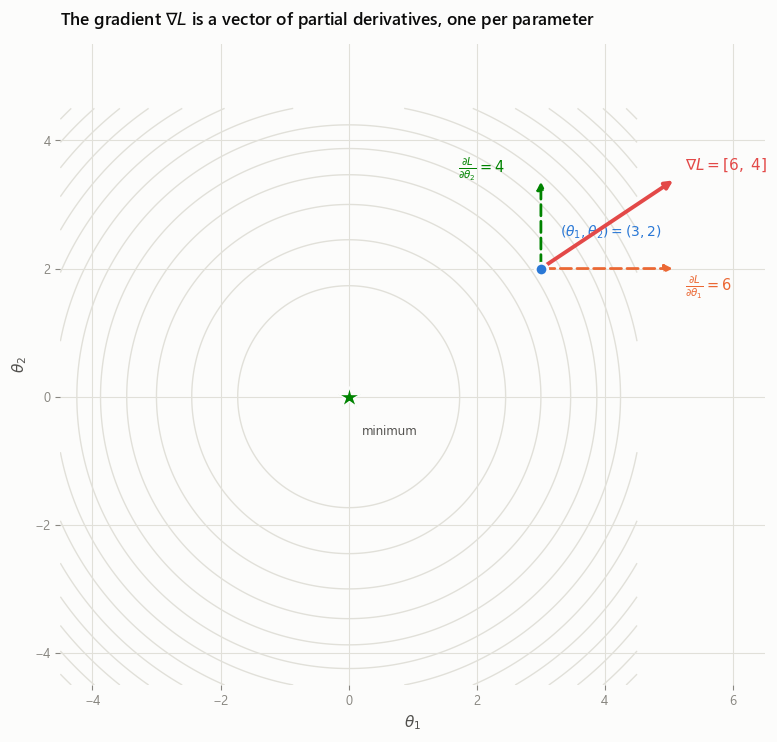

In [34]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, GREEN, ORANGE, RED = "#2a78d6", "#008300", "#eb6834", "#e34948"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 11, "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK_PRIMARY,
    "axes.titlesize": 12, "axes.titleweight": "medium", "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_SECONDARY,
})

def clean_spines(ax, keep=("left", "bottom")):
    for side, spine in ax.spines.items():
        if side not in keep:
            spine.set_visible(False)
        else:
            spine.set_color(BASELINE)
            spine.set_linewidth(1.0)


# =================================================================
# Gradient vector: contour plot of L(x,y) = x^2+y^2, with the
# gradient vector drawn at point (3,2), decomposed into its two
# partial-derivative components
# =================================================================
def L(x, y): return x ** 2 + y ** 2

x0, y0 = 3.0, 2.0
dLdx, dLdy = 2 * x0, 2 * y0  # = 6, 4

xg, yg = np.meshgrid(np.linspace(-4.5, 4.5, 200), np.linspace(-4.5, 4.5, 200))
zg = L(xg, yg)

fig, ax = plt.subplots(figsize=(8, 8))
clean_spines(ax, keep=())
ax.contour(xg, yg, zg, levels=14, colors=[GRIDLINE], linewidths=1.0, zorder=1)

# point
ax.plot(x0, y0, 'o', color=BLUE, markersize=9, markeredgewidth=2,
        markeredgecolor=SURFACE, zorder=4)
ax.annotate(r'$(\theta_1,\theta_2)=(3,2)$', xy=(x0, y0), xytext=(x0 + 0.3, y0 + 0.5),
            fontsize=10, color=BLUE)

# component arrows (partial derivatives), dashed, then full gradient vector, solid
scale = 0.35
ax.annotate('', xy=(x0 + dLdx * scale, y0), xytext=(x0, y0),
            arrowprops=dict(arrowstyle='-|>', color=ORANGE, lw=2, linestyle=(0, (4, 2))))
ax.text(x0 + dLdx * scale + 0.15, y0 - 0.35, r'$\frac{\partial L}{\partial \theta_1}=6$',
        fontsize=10.5, color=ORANGE)

ax.annotate('', xy=(x0, y0 + dLdy * scale), xytext=(x0, y0),
            arrowprops=dict(arrowstyle='-|>', color=GREEN, lw=2, linestyle=(0, (4, 2))))
ax.text(x0 - 1.3, y0 + dLdy * scale + 0.1, r'$\frac{\partial L}{\partial \theta_2}=4$',
        fontsize=10.5, color=GREEN)

ax.annotate('', xy=(x0 + dLdx * scale, y0 + dLdy * scale), xytext=(x0, y0),
            arrowprops=dict(arrowstyle='-|>', color=RED, lw=2.8))
ax.text(x0 + dLdx * scale + 0.15, y0 + dLdy * scale + 0.15,
        r'$\nabla L = [6,\ 4]$', fontsize=11, color=RED, weight='bold')

ax.plot(0, 0, '*', color=GREEN, markersize=16, markeredgewidth=1, markeredgecolor=SURFACE, zorder=4)
ax.annotate('minimum', xy=(0, 0), xytext=(0.2, -0.6), fontsize=9.5, color=INK_SECONDARY)

ax.set_xlim(-4.5, 6.5)
ax.set_ylim(-4.5, 5.5)
ax.set_xlabel(r'$\theta_1$', color=INK_SECONDARY)
ax.set_ylabel(r'$\theta_2$', color=INK_SECONDARY)
ax.set_aspect('equal')
ax.set_title(r"The gradient $\nabla L$ is a vector of partial derivatives, one per parameter",
             fontsize=12.5, loc='left', pad=14)
plt.tight_layout()
plt.show()
plt.close()



## The Full Update Rule

With the gradient defined, the single-variable rule generalizes directly — same idea, just applied to the whole vector at once:

$$\theta \leftarrow \theta - \eta \nabla_\theta L(\theta)$$

This is the general form referenced all the way back in the "Learning as Optimization" section: $\theta^* = \arg\min_\theta L(\theta)$. Gradient descent is the concrete algorithm that walks toward that $\theta^*$, one step at a time, regardless of whether $\theta$ has 1 parameter or 100 million.





---
## The Learning Rate — $\eta$ 

The update rule $\theta \leftarrow \theta - \eta\nabla_\theta L(\theta)$ has one free choice: the learning rate $\eta$. Get it wrong, and gradient descent either crawls or breaks entirely.

- **Too small** ($\eta=0.05$): each step barely moves $\theta$. Training is correct but painfully slow — could take thousands of extra steps to reach the minimum.
- **Good** ($\eta=0.4$): converges to the minimum in just a few steps.
- **Too large** ($\eta=1.05$): each step overshoots the minimum so badly that $\theta$ lands *farther* from the minimum than where it started. The loss grows step after step instead of shrinking — this is **divergence**.

Divergence is a real, common bug: if you ever see a model's loss shoot up to a huge number or `NaN` partway through training, an learning rate that's too large is one of the first things to check.

`There's No Free Best Value`

$\eta$ is a **hyperparameter** — a setting chosen before training starts, not learned by the model itself (contrast with $\theta$, which gradient descent *does* learn). The right value depends on the specific loss landscape, and is usually found by trial and adjustment rather than derived directly. This tension — small steps are safe but slow, large steps are fast but risky — is exactly what modern optimizers (Momentum, RMSProp, Adam, covered later) are designed to manage automatically.




--- 



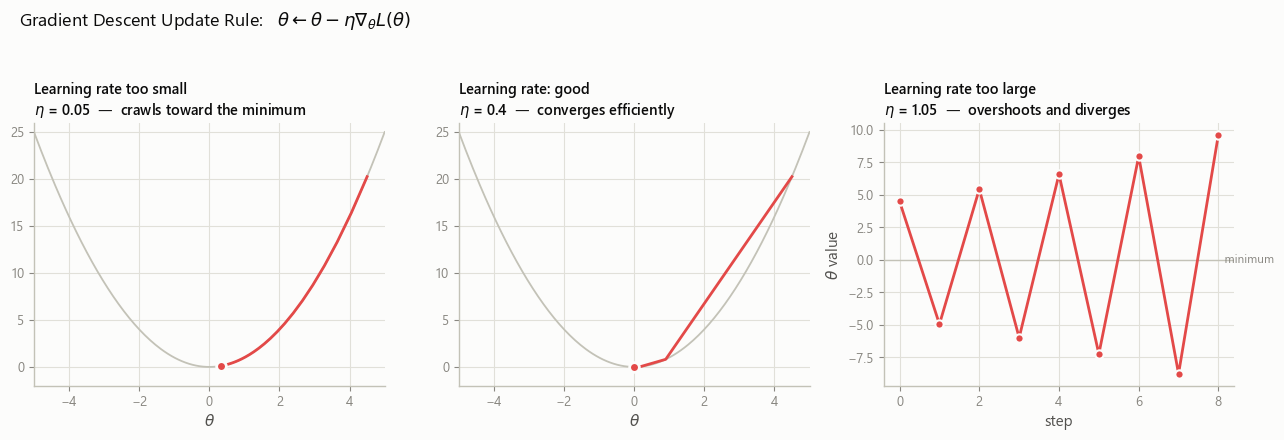

In [36]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style (self-contained, no external file) ---
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, GREEN, ORANGE, RED = "#2a78d6", "#008300", "#eb6834", "#e34948"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 11, "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK_PRIMARY,
    "axes.titlesize": 12, "axes.titleweight": "medium", "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_SECONDARY,
})

def clean_spines(ax, keep=("left", "bottom")):
    for side, spine in ax.spines.items():
        if side not in keep:
            spine.set_visible(False)
        else:
            spine.set_color(BASELINE)
            spine.set_linewidth(1.0)

# =================================================================
# Learning rate effect: too small, good, too large
# =================================================================
def loss(t): return t ** 2
def grad(t): return 2 * t

def run_gd(theta0, lr, steps=12):
    path = [theta0]; t = theta0
    for _ in range(steps):
        t = t - lr * grad(t)
        path.append(t)
    return np.array(path)

theta0 = 4.5
scenarios = [
    (0.05, "Learning rate too small", "crawls toward the minimum"),
    (0.4, "Learning rate: good", "converges efficiently"),
    (1.05, "Learning rate too large", "overshoots and diverges"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
t_range = np.linspace(-5, 5, 200)

for ax, (lr, title, sub) in zip(axes, scenarios):
    clean_spines(ax)
    if lr < 1.0:
        ax.plot(t_range, loss(t_range), color=BASELINE, lw=1.3, zorder=1)
        steps = 25 if lr < 0.1 else 10
        path = np.clip(run_gd(theta0, lr, steps=steps), -5.5, 5.5)
        ax.plot(path, loss(path), '-', color=RED, lw=2, zorder=2)
        ax.plot(path[-1], loss(path[-1]), 'o', color=RED, markersize=7,
                markeredgewidth=2, markeredgecolor=SURFACE, zorder=3)
        ax.set_xlim(-5, 5); ax.set_ylim(-2, 26)
        ax.set_xlabel(r'$\theta$', color=INK_SECONDARY)
    else:
        path = run_gd(theta0, lr, steps=8)
        ax.plot(range(len(path)), path, '-', color=RED, lw=2, zorder=2)
        ax.plot(range(len(path)), path, 'o', color=RED, markersize=6,
                markeredgewidth=1.5, markeredgecolor=SURFACE, zorder=3)
        ax.axhline(0, color=BASELINE, lw=1, linestyle='-', zorder=1)
        ax.text(len(path) - 1, 0, '  minimum', color=INK_MUTED, fontsize=8.5, va='center')
        ax.set_xlabel('step', color=INK_SECONDARY)
        ax.set_ylabel(r'$\theta$ value', color=INK_SECONDARY)
    ax.set_title(f"{title}\n" + r"$\eta$" + f" = {lr}  —  {sub}", fontsize=10.5, loc='left')

fig.suptitle(r"Gradient Descent Update Rule:   $\theta \leftarrow \theta - \eta \nabla_\theta L(\theta)$",
             fontsize=13, color=INK_PRIMARY, x=0.02, ha='left', y=1.04)
plt.tight_layout()
plt.show()


---
## Convex vs Non-Convex Loss Landscapes

Everything so far used a simple bowl-shaped loss ($\theta^2$). That shape is called **convex** — informally, a single smooth valley with exactly one minimum. Real neural network loss landscapes are almost never this well-behaved.

**Definition:** a function is **convex** if it has exactly one minimum, and gradient descent starting from *anywhere* is guaranteed to reach it. A **non-convex** function can have multiple valleys — a **global minimum** (the true best point) and one or more **local minima** (valleys that are locally the lowest point around, but not the lowest point overall).


The critical, practical consequence: on a non-convex surface, **where you start matters**. Gradient descent only ever looks at the *local* slope — it has no way to know a deeper valley exists somewhere else. Once it settles into a local minimum's basin, it stays there; the gradient is zero, so the update rule stops moving $\theta$ at all.

> Deep neural network loss landscapes are highly non-convex — millions of parameters create landscapes with countless local minima. This is one of the deep, still-active research questions in deep learning: empirically, this turns out to matter less than you'd expect (many local minima in high-dimensional networks are "good enough"), but it's the reason training the same network twice, with different random starting weights, can produce slightly different results.


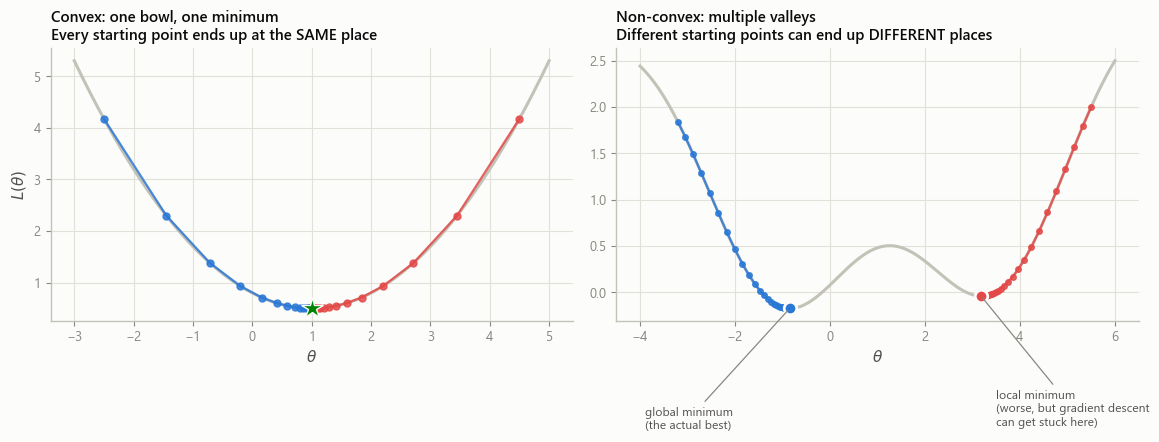

In [37]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style (self-contained, no external file) ---
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, GREEN, ORANGE, RED = "#2a78d6", "#008300", "#eb6834", "#e34948"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 11, "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK_PRIMARY,
    "axes.titlesize": 12, "axes.titleweight": "medium", "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_SECONDARY,
})

def clean_spines(ax, keep=("left", "bottom")):
    for side, spine in ax.spines.items():
        if side not in keep:
            spine.set_visible(False)
        else:
            spine.set_color(BASELINE)
            spine.set_linewidth(1.0)

# =================================================================
# Convex vs non-convex: 1D comparison, two starting points landing
# in different valleys on the non-convex curve
# =================================================================
def convex(x): return 0.3 * (x - 1) ** 2 + 0.5

def nonconvex(x):
    return 0.5 * np.sin(1.3 * x) + 0.08 * (x - 1) ** 2

def nonconvex_grad(x):
    return 0.65 * np.cos(1.3 * x) + 0.16 * (x - 1)

def run_gd_1d(x0, gradfn, lr, steps=60):
    x = x0
    path = [x]
    for _ in range(steps):
        x = x - lr * gradfn(x)
        path.append(x)
    return np.array(path)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Convex panel
ax = axes[0]
clean_spines(ax)
xc = np.linspace(-3, 5, 300)
ax.plot(xc, convex(xc), color=BASELINE, lw=2.2, zorder=1)
for x0, col in [(-2.5, BLUE), (4.5, RED)]:
    path = run_gd_1d(x0, lambda x: 0.6 * (x - 1), lr=0.5, steps=15)
    ax.plot(path, convex(path), 'o-', color=col, lw=1.6, markersize=5, alpha=0.85, zorder=2)
ax.plot(1, convex(1), '*', color=GREEN, markersize=16, markeredgewidth=1,
        markeredgecolor=SURFACE, zorder=4)
ax.set_title("Convex: one bowl, one minimum\nEvery starting point ends up at the SAME place",
             fontsize=11, loc='left')
ax.set_xlabel(r'$\theta$', color=INK_SECONDARY)
ax.set_ylabel(r'$L(\theta)$', color=INK_SECONDARY)

# Non-convex panel
ax = axes[1]
clean_spines(ax)
xn = np.linspace(-4, 6, 400)
ax.plot(xn, nonconvex(xn), color=BASELINE, lw=2.2, zorder=1)
starts = [(-3.2, BLUE), (5.5, RED)]
for x0, col in starts:
    path = run_gd_1d(x0, nonconvex_grad, lr=0.15, steps=60)
    path = np.clip(path, -4, 6)
    ax.plot(path, nonconvex(path), 'o-', color=col, lw=1.6, markersize=4, alpha=0.85, zorder=2)
    ax.plot(path[-1], nonconvex(path[-1]), 'o', color=col, markersize=9,
            markeredgewidth=2, markeredgecolor=SURFACE, zorder=3)

# global minimum near x=-0.85, local minimum near x=3.18
ax.annotate('global minimum\n(the actual best)', xy=(-0.85, nonconvex(-0.85)),
            xytext=(-3.9, nonconvex(-0.85) - 1.3), fontsize=8.7, color=INK_SECONDARY,
            arrowprops=dict(arrowstyle='-', color=INK_MUTED, lw=0.9))
ax.annotate('local minimum\n(worse, but gradient descent\ncan get stuck here)', xy=(3.18, nonconvex(3.18)),
            xytext=(3.5, nonconvex(3.18) - 1.4), fontsize=8.7, color=INK_SECONDARY,
            arrowprops=dict(arrowstyle='-', color=INK_MUTED, lw=0.9))

ax.set_title("Non-convex: multiple valleys\nDifferent starting points can end up DIFFERENT places",
             fontsize=11, loc='left')
ax.set_xlabel(r'$\theta$', color=INK_SECONDARY)

plt.tight_layout()
plt.show()


## Saddle Points: A Trickier Kind of Stuck

There's a second way gradient descent can stall, more common in high dimensions than local minima: **saddle points**.

**Definition:** a saddle point is a point where the gradient is exactly zero, but it's neither a minimum nor a maximum — it's a minimum *along some directions* and a maximum *along others*, simultaneously.


At the point $(\theta_1,\theta_2)=(0,0)$ for $L=\theta_1^2-\theta_2^2$: moving along $\theta_1$, the loss goes up in both directions (looks like a minimum). Moving along $\theta_2$, the loss goes down in both directions (looks like a maximum). The gradient $\nabla L = [0, 0]$ at this exact point — so the plain update rule $\theta \leftarrow \theta - \eta\nabla L$ produces **zero movement**, exactly like at a true minimum, even though this is not a good place to stop.

> In very high-dimensional loss landscapes (like a real neural network's), saddle points are actually far more common than local minima. This is one of the key motivations for the momentum-based optimizers covered later — they carry "velocity" through flat, zero-gradient regions instead of stopping dead the moment the gradient hits zero.


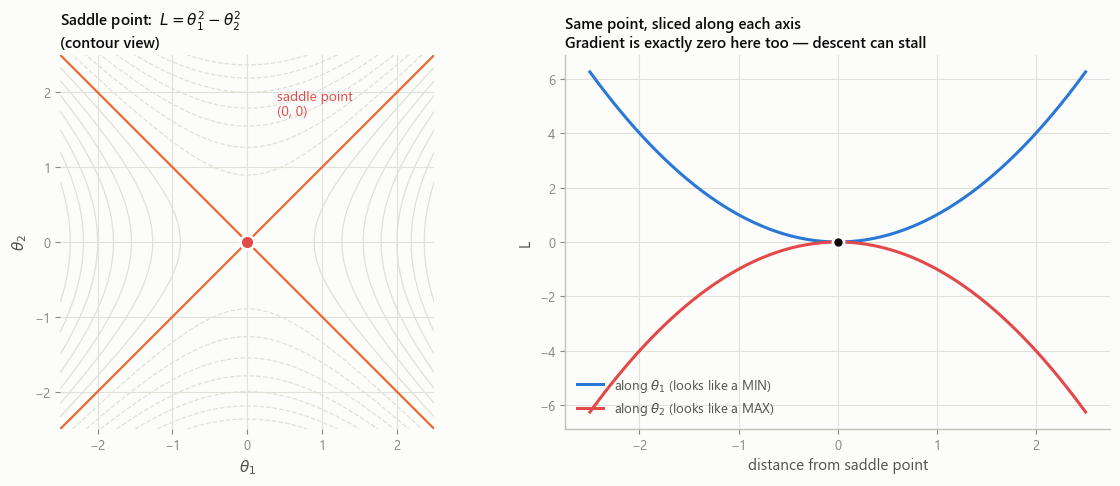

In [38]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- style (self-contained, no external file) ---
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, GREEN, ORANGE, RED = "#2a78d6", "#008300", "#eb6834", "#e34948"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 11, "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK_PRIMARY,
    "axes.titlesize": 12, "axes.titleweight": "medium", "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_SECONDARY,
})

def clean_spines(ax, keep=("left", "bottom")):
    for side, spine in ax.spines.items():
        if side not in keep:
            spine.set_visible(False)
        else:
            spine.set_color(BASELINE)
            spine.set_linewidth(1.0)

# =================================================================
# Saddle point: contour view (X-shaped zero-contour) + cross-section
# showing minimum along one axis, maximum along the other
# =================================================================
def saddle(x, y): return x**2 - y**2

xg, yg = np.meshgrid(np.linspace(-2.5, 2.5, 200), np.linspace(-2.5, 2.5, 200))
zg = saddle(xg, yg)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
clean_spines(ax, keep=())
ax.contour(xg, yg, zg, levels=16, colors=[GRIDLINE], linewidths=0.9, zorder=1)
ax.contour(xg, yg, zg, levels=[0], colors=[ORANGE], linewidths=1.6, zorder=2)
ax.plot(0, 0, 'o', color=RED, markersize=10, markeredgewidth=2, markeredgecolor=SURFACE, zorder=4)
ax.annotate('saddle point\n(0, 0)', xy=(0, 0), xytext=(0.4, 1.7), fontsize=10, color=RED)
ax.set_xlabel(r'$\theta_1$', color=INK_SECONDARY)
ax.set_ylabel(r'$\theta_2$', color=INK_SECONDARY)
ax.set_aspect('equal')
ax.set_title(r"Saddle point:  $L=\theta_1^2-\theta_2^2$" + "\n(contour view)", fontsize=11, loc='left')

ax = axes[1]
clean_spines(ax)
t = np.linspace(-2.5, 2.5, 200)
ax.plot(t, t**2, color=BLUE, lw=2.2, label=r'along $\theta_1$ (looks like a MIN)')
ax.plot(t, -(t**2), color=RED, lw=2.2, label=r'along $\theta_2$ (looks like a MAX)')
ax.plot(0, 0, 'o', color=INK_PRIMARY, markersize=8, markeredgewidth=2,
        markeredgecolor=SURFACE, zorder=4)
ax.legend(loc='lower left')
ax.set_xlabel('distance from saddle point', color=INK_SECONDARY)
ax.set_ylabel('L', color=INK_SECONDARY)
ax.set_title("Same point, sliced along each axis\nGradient is exactly zero here too — descent can stall",
              fontsize=11, loc='left')

plt.tight_layout()
plt.show()


---
## Gradient Descent Variants

The update rule $\theta \leftarrow \theta - \eta\nabla_\theta L(\theta)$ says nothing about *how much data* to use when computing $\nabla_\theta L$. That choice matters enormously in practice, and gives three variants:

<img src="image/gradient-desent-comparisions.png" alt="gradient-desent-comparisions.png" width="600" >

- **Batch Gradient Descent (BGD)** — computes the gradient using the **entire training dataset** for every single update. Accurate and stable (the true gradient, no approximation), but computationally expensive: one update requires a full pass over all the data, so training is slow for large datasets.
- **Stochastic Gradient Descent (SGD)** — computes the gradient using **just one training example** at a time. Extremely fast per step, but the gradient estimate is noisy (a single example is a rough proxy for the whole dataset's gradient) — the path toward the minimum zigzags rather than moving smoothly.
- **Mini-batch Gradient Descent** — the practical middle ground: computes the gradient over a **small batch** (commonly 32–256 examples) at a time. This is what virtually all real deep learning training actually uses.

**The three paths compared** on the same loss surface, starting from the same point:


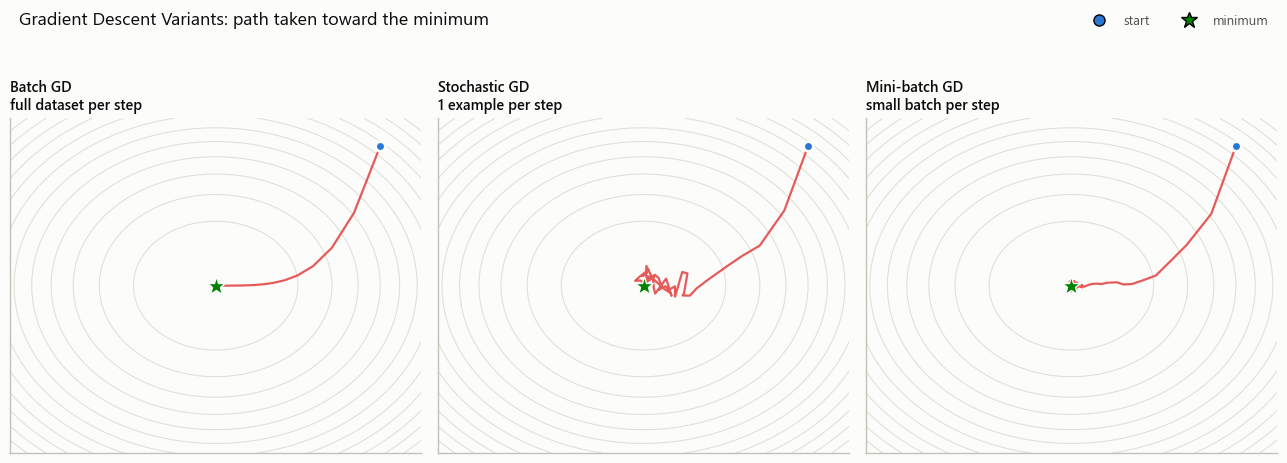

In [41]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- style (self-contained, no external file) ---
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, GREEN, ORANGE, RED = "#2a78d6", "#008300", "#eb6834", "#e34948"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 11, "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK_PRIMARY,
    "axes.titlesize": 12, "axes.titleweight": "medium", "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": GRIDLINE, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "legend.frameon": False, "legend.fontsize": 9.5, "legend.labelcolor": INK_SECONDARY,
})

def clean_spines(ax, keep=("left", "bottom")):
    for side, spine in ax.spines.items():
        if side not in keep:
            spine.set_visible(False)
        else:
            spine.set_color(BASELINE)
            spine.set_linewidth(1.0)

# =================================================================
# GD variants: path taken toward the minimum, on the same surface
# =================================================================
rng = np.random.default_rng(7)

def loss2d(x, y): return x**2 + 3 * y**2
def grad2d_true(x, y): return np.array([2 * x, 6 * y])

def run_2d(lr, noise_scale, steps=40):
    pos = np.array([4.0, 2.5]); path = [pos.copy()]
    for _ in range(steps):
        g = grad2d_true(*pos) + rng.normal(0, noise_scale, size=2)
        pos = pos - lr * g
        path.append(pos.copy())
    return np.array(path)

paths = [
    ("Batch GD", "full dataset per step", run_2d(lr=0.08, noise_scale=0.0)),
    ("Stochastic GD", "1 example per step", run_2d(lr=0.08, noise_scale=1.8)),
    ("Mini-batch GD", "small batch per step", run_2d(lr=0.08, noise_scale=0.5)),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
xg, yg = np.meshgrid(np.linspace(-5, 5, 100), np.linspace(-3, 3, 100))
zg = loss2d(xg, yg)

for ax, (title, sub, path) in zip(axes, paths):
    clean_spines(ax)
    ax.contour(xg, yg, zg, levels=12, colors=[GRIDLINE], linewidths=0.8, zorder=1)
    ax.plot(path[:, 0], path[:, 1], '-', color=RED, lw=1.6, alpha=0.9, zorder=2)
    ax.plot(path[0, 0], path[0, 1], 'o', color=BLUE, markersize=7,
            markeredgewidth=2, markeredgecolor=SURFACE, zorder=3)
    ax.plot(0, 0, '*', color=GREEN, markersize=14, markeredgewidth=1,
            markeredgecolor=SURFACE, zorder=3)
    ax.set_title(f"{title}\n{sub}", fontsize=10.5, loc='left')
    ax.set_xlim(-5, 5); ax.set_ylim(-3, 3)
    ax.set_xticks([]); ax.set_yticks([])

legend_elems = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=BLUE, markersize=8, label='start'),
    Line2D([0], [0], marker='*', color='none', markerfacecolor=GREEN, markersize=12, label='minimum'),
]
fig.legend(handles=legend_elems, loc='upper right', ncol=2, bbox_to_anchor=(0.99, 1.06),
           frameon=False, fontsize=9.5, labelcolor=INK_SECONDARY)

fig.suptitle("Gradient Descent Variants: path taken toward the minimum",
             fontsize=13, color=INK_PRIMARY, x=0.02, ha='left', y=1.04)
plt.tight_layout()
plt.show()




Batch GD's path is smooth because it always uses the true, exact gradient. Stochastic GD's path is visibly jagged — the noisy per-example gradient causes it to overshoot and correct constantly rather than settling cleanly. Mini-batch sits between the two: noisier than Batch, much smoother than pure SGD.

<img src="image/convergence-of-gradient-methods.png" alt="convergence-of-gradient-methods.png" width="400" >

### Why the Noise Isn't Just a Downside

SGD and Mini-batch's noisy path isn't purely a cost — it has a real benefit tied directly back to the last section. That noise can knock $\theta$ *out* of a shallow local minimum or off a saddle point, since the gradient estimate at any single step isn't exactly zero even where the *true* full-dataset gradient would be. Batch GD, with its exact gradient, has no such luck — if it lands exactly on a saddle point or in a local minimum, it stops there for good.

> This "batch size" choice matters again later, when we reach modern optimizers (Momentum, RMSProp, Adam) — all of them are built on top of Mini-batch Gradient Descent, adding tricks to make the noisy path smoother and faster while keeping its ability to escape bad flat regions.


---
## What Gradient Descent Does *Not* Tell You

Every example in this section computed $\nabla_\theta L$ by hand — we already knew the formula for $L(\theta)$, so we could just differentiate it directly ($L(\theta)=\theta^2 \Rightarrow L'(\theta)=2\theta$).

A real neural network's loss is not one clean formula like that. Recall the forward pass: input → layer 1 → activation → layer 2 → activation → ... → $\hat{y}$ → loss. $L$ is a function of **every weight and bias in every layer**, composed through dozens of nested operations. Writing out $\frac{\partial L}{\partial w}$ by hand for a weight buried three layers deep, the way we did above, would be an enormous, error-prone algebra problem — and would need to be redone from scratch for every different network architecture.

**Gradient descent tells you what to do once you have the gradient** ($\theta \leftarrow \theta - \eta\nabla_\theta L$). It says nothing about *how to efficiently compute* $\nabla_\theta L$ for a deep, composed function with millions of parameters.

That missing piece — a fast, systematic algorithm for computing the exact gradient of the loss with respect to *every* parameter in a deep network, all at once — is **Backpropagation**. It is not a different optimization strategy; it is the engine that feeds gradient descent the numbers it needs to run.



---

<details>
<summary>

**`❓ Question:`**

Consider a neuron with input vector $(x=[x_1,x_2])$, weight vector $(w=[w_1,w_2])$, and bias $(b)$. Let the activation be sigmoid:

$$
f(z)=\frac{1}{1+e^{-z}}, \qquad z=w_1x_1+w_2x_2+b
$$

Which of the following are correct about the gradient of the output with respect to $(w_1)$?

> **A.** $$\frac{\partial f}{\partial w_1}=f(z)(1-f(z))x_1$$

> **B.** $$\left|\frac{\partial f}{\partial w_1}\right|\le0.25|x_1|$$

> **C.** Gradient vanishes for large $|z|$

> **D.** It is independent of bias $(b)$

</summary>

---

**`Solution:`**

The neuron first computes the weighted sum

$$
z=w_1x_1+w_2x_2+b
$$

where

- $x_1,x_2$ → Input features.
- $w_1,w_2$ → Weights.
- $b$ → Bias.
- $z$ → Input to the activation function.

The output of the neuron is then computed using the **sigmoid activation function**

$$
f(z)=\frac{1}{1+e^{-z}}
$$

The sigmoid function always produces an output between **0 and 1**.

To compute the gradient with respect to $w_1$, we use the **Chain Rule**.

$$ \frac{\partial f}{\partial w_1}  = \frac{\partial f}{\partial z} \cdot \frac{\partial z}{\partial w_1} $$

Since

$$
\frac{\partial f}{\partial z}=f(z)(1-f(z))
$$

and

$$
\frac{\partial z}{\partial w_1}=x_1,
$$

we get

$$
\boxed{\frac{\partial f}{\partial w_1}=f(z)(1-f(z))x_1}
$$

---

> **Option A ✅ :**
>
> $$\frac{\partial f}{\partial w_1}=f(z)(1-f(z))x_1$$

This is exactly the result obtained using the **Chain Rule**.

---

> **Option B ✅ :**
>
> $$\left|\frac{\partial f}{\partial w_1}\right|\le0.25|x_1|$$

The derivative of the sigmoid function is

$$
f(z)(1-f(z)).
$$

Its maximum value is

$$
0.25,
$$

which occurs when

$$
f(z)=0.5
\quad\text{(i.e., }z=0\text{)}.
$$

Therefore,

$$ \left|\frac{\partial f}{\partial w_1}\right| = |f(z)(1-f(z))x_1| \le0.25|x_1|. $$

---

> **Option C ✅ :**
>
> Gradient vanishes for large $|z|$

When $z$ becomes very large (positive or negative),

the sigmoid output becomes approximately

- $1$ (for large positive $z$), or
- $0$ (for large negative $z$).

In both cases,

$$
f(z)(1-f(z))
\approx0,
$$

so

$$
\frac{\partial f}{\partial w_1}\approx0.
$$

This is known as the **Vanishing Gradient Problem**.


---

> **Option D ❌ :**
>
> It is independent of bias $(b)$

The gradient is

$$
\frac{\partial f}{\partial w_1}=f(z)(1-f(z))x_1.
$$

Notice that

$$
f(z)
$$

depends on

$$
z=w_1x_1+w_2x_2+b.
$$

Since $b$ affects $z$, it also affects $f(z)$ and therefore the gradient.

Hence, the gradient is **not independent of the bias**.


</details>

---

---

<details>
<summary>

**`❓ Question:`**

Which of the following is/are true about gradient descent and learning rate?

> **A.** The direction of steepest descent is gradient.

> **B.** Setting learning rate to a very high value helps us reach minima faster.

> **C.** A very small learning rate guarantees convergence to the global minimum.

> **D.** Gradient descent always guarantees finding the global minimum, regardless of the loss surface.

> **E.** None of the above.

</summary>

---

**`Solution:`**

Before solving the question, let's understand the important terms.

- **Loss Function ($L$)** → Measures how wrong the model's prediction is.

- **Gradient ($\nabla L$)** → Indicates **how the loss changes** with respect to the model's parameters (weights).

  It points in the direction where the loss **increases the fastest**.

- **Gradient Descent** → An optimization algorithm that updates the weights to **reduce the loss**.

  It updates the weights using

  $$ W_{\text{new}} = W_{\text{old}} - \eta \nabla L $$

  where

  - $W$ → Weight(s) of the model.
  - $\eta$ (eta) → Learning Rate.
  - $\nabla L$ → Gradient of the loss.

- **Learning Rate ($\eta$)** → Controls **how big a step** is taken while updating the weights.

  - Small learning rate → Small steps.
  - Large learning rate → Large steps.

---

> **Option A ❌ :** The direction of steepest descent is gradient.

The **gradient** points in the direction of the **steepest increase** in the loss.

Gradient Descent moves in the **opposite direction** of the gradient to reduce the loss.

That is why the update rule is

$$ W_{\text{new}} = W_{\text{old}} - \eta \nabla L. $$

The **minus sign** tells us to move opposite to the gradient.

So,

- Gradient → Steepest **increase**.
- Negative Gradient ($-\nabla L$) → Steepest **descent**.

Therefore, this statement is incorrect.

---

> **Option B ❌ :** Setting learning rate to a very high value helps us reach minima faster.

A very high learning rate takes **very large steps**.

Instead of moving toward the minimum, the algorithm may

- overshoot the minimum,
- oscillate around it,
- or even diverge.

So, a very high learning rate does **not** guarantee faster convergence.

---

> **Option C ❌ :** A very small learning rate guarantees convergence to the global minimum.

A very small learning rate only means **small updates**.

Although it may make training more stable, it **does not guarantee** reaching the **global minimum**.

The optimizer can still get stuck in

- a **local minimum**, or
- a **saddle point**,

depending on the shape of the loss function.

---

> **Option D ❌ :** Gradient descent always guarantees finding the global minimum, regardless of the loss surface.

This is false.

If the loss function has many local minima (common in deep learning), Gradient Descent may stop at one of them instead of the global minimum.

It does **not** guarantee finding the best possible minimum.

---

> **Option E ✅ :** None of the above.

Since Options **A, B, C, and D** are all incorrect,

✅ **Option E is Correct.**

---

</details>

---

---
---
---
---
# Backpropagation 
---
---
---
---
// Calculating the Gradients 



## The Problem

Gradient Descent (previous section) gave the rule for *using* a gradient: $\theta \leftarrow \theta - \eta\nabla_\theta L(\theta)$. It said nothing about how to *compute* $\nabla_\theta L$ efficiently when $L$ is the output of a deep, multi-layer network — a composition of dozens of operations, with millions of parameters buried at every depth.

**Backpropagation** is that missing algorithm: a systematic, efficient method for computing the exact gradient of the loss with respect to *every* parameter in a network, in a single backward sweep. It is not a competing idea to gradient descent — it's the engine that supplies gradient descent with the numbers it needs on every single step of training.

<img src="image/backpropogation-engine-chain-rule.png" alt="backpropagation-chain-rule.png" width="550"   >


<img src="image/scaler-case-simple-chain.png" alt="scaler-case-simple-chain.png" width="400"    >

--- 


## Prerequisite: The Chain Rule

Backpropagation is, at its core, one calculus rule applied repeatedly and systematically: the **chain rule**.

**Definition:** if $y$ depends on $u$, and $u$ depends on $x$, then the rate of change of $y$ with respect to $x$ is the *product* of the two local rates of change along that path:

$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$


In plain words: to find out how much wiggling $x$ ultimately affects $y$, multiply together how much each step in the chain amplifies (or shrinks) that wiggle. This is the entire mathematical machinery behind backpropagation — a neural network's forward pass is nothing but a long chain of exactly this kind of dependency ($x \to z_1 \to a_1 \to z_2 \to a_2 \to \ldots \to L$), and the chain rule is what lets us compute $\frac{\partial L}{\partial \theta}$ for a $\theta$ buried arbitrarily deep in that chain, by multiplying local derivatives step by step, backward.

> Notice this already matches your existing intuition: it's the same idea previewed in the Modern Neuron section, where composing linear layers multiplies weight matrices together. The chain rule is the same composition principle, applied to derivatives instead of the functions themselves.

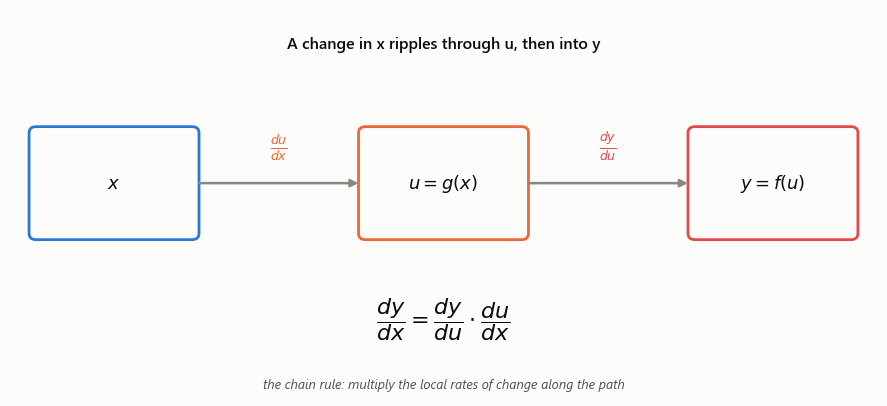

In [42]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- style (self-contained, no external file) ---
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, GREEN, ORANGE, RED = "#2a78d6", "#008300", "#eb6834", "#e34948"

mpl.rcParams.update({
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 11, "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK_PRIMARY,
    "axes.titlesize": 12, "axes.titleweight": "medium", "axes.linewidth": 1.0,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
})

# =================================================================
# Chain rule refresher: y depends on u depends on x.
# A change in x ripples through u to y -- the chain rule multiplies
# the two local rates of change together.
# =================================================================
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.axis('off')
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)

boxes = [
    (1.2, r'$x$', BLUE),
    (5.0, r'$u = g(x)$', ORANGE),
    (8.8, r'$y = f(u)$', RED),
]
for bx, label, color in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((bx - 0.9, 2.1), 1.8, 1.3, boxstyle="round,pad=0.08",
                                           linewidth=2, edgecolor=color, facecolor=SURFACE, zorder=2))
    ax.text(bx, 2.75, label, ha='center', va='center', fontsize=13, zorder=3)

ax.annotate('', xy=(4.05, 2.75), xytext=(2.15, 2.75),
            arrowprops=dict(arrowstyle='-|>', color=INK_MUTED, lw=1.8))
ax.text(3.1, 3.15, r'$\frac{du}{dx}$', fontsize=13, color=ORANGE, ha='center')

ax.annotate('', xy=(7.85, 2.75), xytext=(5.95, 2.75),
            arrowprops=dict(arrowstyle='-|>', color=INK_MUTED, lw=1.8))
ax.text(6.9, 3.15, r'$\frac{dy}{du}$', fontsize=13, color=RED, ha='center')

ax.text(5.0, 0.9, r'$\dfrac{dy}{dx} = \dfrac{dy}{du} \cdot \dfrac{du}{dx}$',
        fontsize=16, ha='center', color=INK_PRIMARY)
ax.text(5.0, 0.1, "the chain rule: multiply the local rates of change along the path",
        fontsize=9.5, ha='center', color=INK_SECONDARY, style='italic')

ax.text(5.0, 4.5, "A change in x ripples through u, then into y",
        fontsize=11.5, ha='center', color=INK_PRIMARY, weight='medium')

plt.tight_layout()
plt.show()



<img src="image/visulizing-computation-flow-of-derivatives.png" alt="visulizing-computation-flow-of-derivatives.png" width="400"    >



<img src="image/backward-propagation-scalar-example.png" alt="backward-propagation-scalar-example.png" width="400"    >


<img src="image/backpropagation-scalar-example(2).png" alt="backpropagation-scalar-example(2).png" width="400"    >









<img src="image/backpropagation-in-multilayer-perceptron.png" alt="backpropagation-in-multilayer-perceptron.png" width="400"    >





<img src="image/backpropagation-in-multilayer-perceptron-(2).png" alt="backpropagation-in-multilayer-perceptron-(2).png" width="400"    >





<img src="image/theweighted-rule-full-derivation.png" alt="theweighted-rule-full-derivation.png" width="400"   >






<img src="image/Screenshot 2026-03-14 192725.png" alt="Screenshot 2026-03-14 192725.png" width="400"    >





<img src="image/Screenshot 2026-03-14 192758.png" alt="Screenshot 2026-03-14 192758.png" width="400"    >





<img src="image/Screenshot 2026-03-14 192851.png" alt="Screenshot 2026-03-14 192851.png" width="400"    >



<img src="image/Screenshot 2026-03-14 192925.png" alt="Screenshot 2026-03-14 192925.png" width="400"    >




---

<details>
<summary>

**`❓ Question:`**

Consider the following MLP architecture used for a binary classification problem with label 0 or 1.

- The input is in $R^2$.
- There is one hidden layer with **2 neurons**.
- The output layer has **1 neuron**.

<img src="image/question-on-mlp-diagram.png" alt="question-on-mlp-diagram.png" width="320" >


The loss function is **Binary Cross Entropy (BCE)**:

$$ L(\hat{y},y)=-y\ln(\hat{y})-(1-y)\ln(1-\hat{y}) $$

where

- $\hat{y}$ is the predicted probability of class **1**.
- $y$ is the true label.

The **sigmoid activation function** is used for **every neuron**.

Ignore all biases. All weights are initialized to **1**. The network receives $ x=\begin{bmatrix}0\\0\end{bmatrix} $ and the true label is $ y=1. $

Based on this, answer the following question.

**What is the value of $\hat{y}$ in the first forward pass?** Round your answer to **two decimal places**.

</summary>

---

**`Solution:`**

Before solving the question, let's understand the notation.

- **$x$** → Input to the neural network.

- **$w$** → Weights connecting one neuron to another.

- **Sigmoid Activation**

  $$ \sigma(z)=\frac{1}{1+e^{-z}} $$

  It converts any real number into a value between **0 and 1**.

- **$\hat{y}$ (y hat)** → The **prediction made by the network**.

  Since this is a **binary classification** problem,

  $$ 0 \le \hat{y} \le 1. $$

  It represents the **predicted probability** that the input belongs to class **1**.

---

The input is

$$ x=\begin{bmatrix}0\\0\end{bmatrix}. $$

All weights are **1** and biases are ignored.

---

The input to the **first hidden neuron** is

$$ z_1=(1\times0)+(1\times0)=0. $$

Applying the sigmoid activation,

$$ h_1=\sigma(0)=0.5. $$

---

Similarly, the **second hidden neuron** also receives

$$ z_2=(1\times0)+(1\times0)=0. $$

Therefore,

$$ h_2=\sigma(0)=0.5. $$

The hidden layer outputs are

$$
\begin{bmatrix}
0.5\\
0.5
\end{bmatrix}.
$$

---

Now compute the input to the output neuron.

Since both weights are **1**,

$$ z=(1\times0.5)+(1\times0.5)=1. $$

Applying the sigmoid again,

$$ \hat{y}=\sigma(1)=\frac{1}{1+e^{-1}}\approx0.731. $$

Rounded to two decimal places,

$$ \boxed{\hat{y}=0.73} $$

</details>

---

---

<details>
<summary>

**`❓ Question:`**

Using the same network and data from the previous question,

What is the **loss value** in the first forward pass?

Round your answer to **two decimal places**.

</summary>

---

**`Solution:`**

Recall from the previous question that the network predicted

$$ \hat{y}=0.73. $$

Also,

- True label:

  $$ y=1 $$

- The loss function is **Binary Cross Entropy (BCE)**

  $$ L(\hat{y},y)=-y\ln(\hat{y})-(1-y)\ln(1-\hat{y}). $$

---

Let's substitute the values.

Since

$$ y=1, $$

the second term becomes

$$ (1-y)=0. $$

Therefore,

$$ L=-1\times\ln(\hat{y})-0\times\ln(1-\hat{y}). $$

The second term becomes zero, so we get

$$ L=-\ln(\hat{y}). $$

Substitute

$$ \hat{y}=0.73. $$

$$ L=-\ln(0.73). $$

Using a calculator,

$$ L\approx0.3147. $$

Rounded to two decimal places,

$$ \boxed{L=0.31}. $$

---


</details>

---

---

<details>
<summary>

**`❓ Question:`**

Using the backpropagation algorithm with learning rate as **1**, calculate the updated value for weight

$$ w_{31}. $$

Round off your answer to **two decimal places**.

</summary>

---

**`Solution:`**

Before solving the question, let's understand the notation.

- **Backpropagation** → The algorithm used to compute the gradient of the loss with respect to every weight in the network.

- **Learning Rate ($\eta$)** → Controls how much the weights are updated in one step.

  Here,

  $$ \eta = 1. $$

- **Weight Update Rule**

  Gradient Descent updates every weight using

  $$ w_{\text{new}}=w_{\text{old}}-\eta\frac{\partial L}{\partial w}. $$

The question asks us to update the weight

$$ w_{31}, $$

which connects

- Hidden Neuron 1
- Output Neuron

---

From the previous questions, we already know

$$ h_1=0.5 $$

$$ h_2=0.5 $$

$$ z=1 $$

$$ \hat y=\sigma(1)\approx0.73 $$

and

$$ y=1. $$

---

For a sigmoid output neuron with **Binary Cross Entropy Loss**, the gradient with respect to the output neuron input simplifies to

$$ \frac{\partial L}{\partial z}=\hat y-y. $$

Substituting the values,

$$ \frac{\partial L}{\partial z}=0.73-1=-0.27. $$

---

Now we compute the gradient for

$$ w_{31}. $$

The formula is

$$ \frac{\partial L}{\partial w_{31}}=\left(\frac{\partial L}{\partial z}\right)\times h_1. $$

Here,

- $h_1$ is the output of Hidden Neuron 1.
- We already found

  $$ h_1=0.5. $$

Therefore,

$$ \frac{\partial L}{\partial w_{31}}=(-0.27)\times0.5=-0.135. $$

---

Now update the weight.

Initially,

$$ w_{31}=1. $$

Using Gradient Descent,

$$ w_{\text{new}}=w_{\text{old}}-\eta\frac{\partial L}{\partial w_{31}}. $$

Substitute the values,

$$ w_{31}=1-1\times(-0.135). $$

$$ w_{31}=1+0.135. $$

$$ w_{31}=1.135. $$

Rounded to two decimal places,

$$ \boxed{w_{31}=1.14}. $$

---

**Why did the weight increase instead of decrease?**

The gradient is

$$ -0.135. $$

The update rule is

$$ w_{\text{new}}=w_{\text{old}}-\eta\times(\text{gradient}). $$

Since the gradient is **negative**,

subtracting a negative number becomes **addition**.

That is,

$$ 1-(-0.135)=1+0.135. $$

So the weight **increases**.

This makes sense because

- the true label is **1**,
- but the network predicted only **0.73**.

Increasing the weight will increase the output in the next forward pass, making the prediction closer to **1**.

</details>

---

---

<details>
<summary>

**`❓ Question:`**

Which of the following indicate(s) **overfitting**?

> **A.** Training loss and validation loss both high.

> **B.** Training loss high, validation loss low.

> **C.** Training loss low, validation loss high.

> **D.** Both training and validation loss decrease steadily.

</summary>

---

**`Solution:`**

Before solving the question, let's understand the important terms.

- **Training Data** → The data used to **train** the neural network.

- **Validation Data** → New data that the model **has not seen during training**. It is used to check how well the model generalizes to unseen data.

- **Loss** → Measures how wrong the model's predictions are.

  - **Low loss** → Better predictions.
  - **High loss** → Worse predictions.

---

### What is Overfitting?

A model is said to **overfit** when it **memorizes the training data** instead of learning general patterns.

As a result,

- it performs **very well on the training data**, but
- performs **poorly on unseen (validation) data**.

This means

```text
Training Loss    → Low
Validation Loss  → High
```

---

> **Option A ❌ :** Training loss and validation loss both high.

If both losses are high, the model is performing poorly on **both** training and validation data.

This is called **underfitting**, not overfitting.

```text
Training Loss    ↑ High
Validation Loss  ↑ High
```

---

> **Option B ❌ :** Training loss high, validation loss low.

This situation is generally not expected.

If the model cannot even fit the training data, it is very unlikely to perform better on unseen validation data.

---

> **Option C ✅ :** Training loss low, validation loss high.

This is the classic sign of **overfitting**.

The model has learned the training data very well but fails to generalize to new data.

```text
Training Loss    ↓ Low
Validation Loss  ↑ High
```

✅ **Option C is Correct.**

---

> **Option D ❌ :** Both training and validation loss decrease steadily.

This is a sign that the model is learning well and improving on both datasets.

It does **not** indicate overfitting.

---

💡 **Easy Way to Remember**

| Situation | Meaning |
|-----------|---------|
| Training Loss ↓, Validation Loss ↓ | ✅ Good Training |
| Training Loss ↑, Validation Loss ↑ | ❌ Underfitting |
| Training Loss ↓, Validation Loss ↑ | ✅ Overfitting |

A simple analogy:

- **Training Data** → Questions you practiced before the exam.
- **Validation Data** → New questions in the actual exam.

If you score

- **100% on practice questions** but
- **40% on new exam questions**,

then you've **memorized** the practice questions instead of understanding the concepts.

This is exactly what **overfitting** means.

</details>

---
